# Genetic Algorithm for Gas Turbine Health Indicator Estimation

Experiment Framework on a single measurment.

This notebook implements a **Genetic Algorithm (GA)** to solve the **inverse problem** in gas turbine engine health monitoring.


### Systematic Experiments with Multiple Scenarios

This notebook includes:
1. **All original plots** (convergence, 2D/3D search space, ablation)
2. **Multi-scenario experiments** (1-4 contexts × 1-3 sensors)
3. **Clean and noisy data** comparison
4. **Uses existing original and noisy CSV file**

---

For details about the problem and the parameter tuning please refer to :

- `the readme file`
-  `The technical documentation` inside the Reports folder


**Note** : Update the ga_config.py if you have new configuration for the GA

In [7]:
import sys
from pathlib import Path

# Add project root to sys.path
project_root = Path().resolve().parent
sys.path.append(str(project_root))


In [8]:
project_root 

PosixPath('/home/ensai/Documents/dataviz-course/SDSPROJECT/TO_PUSH/TO_PUSH_TRUE/scenaries/V3SAFRAN_ENSAI_2025/CLIMB1_genetic algorithm/simulationv1')

In [9]:
# include GA pachages
from functions.GA_single_experiment import *

from functions.ga_config import *


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
import time
import os
import pickle
import warnings
from datetime import datetime
import copy

warnings.filterwarnings('ignore')

# Simulator imports
from odsmr.sensors import HPC_Tout, HP_Nmech, HPC_Tin, LPT_Tin, Fuel_flow, HPC_Pout_st, LP_Nmech
from odsmr.predefined_flight_conditions import Cruise_DeckSMR, Takeoff_DeckSMR, Climb1_DeckSMR, Climb2_DeckSMR
from odsmr.generation_functions import decksmr_1forall
from odsmr.constants import ROOT_OPENDECK, STATE_LABELS, STATE_BOUNDS


from scipy.stats import qmc


np.random.seed(42)
print("Imports OK")

Imports OK


In [11]:
print("="*80)
print("ALL 10 HEALTH INDICATORS")
print("="*80)
print(f"{'Index':<6} {'Label':<35} {'Lower':>10} {'Upper':>10}")
print("-"*65)
for i, label in enumerate(STATE_LABELS):
    bounds = STATE_BOUNDS[label]
    print(f"{i:<6} {label:<35} {bounds[0]:>10.3f} {bounds[1]:>10.3f}")

ALL 10 HEALTH INDICATORS
Index  Label                                    Lower      Upper
-----------------------------------------------------------------
0      deg_CmpBst_s_mapEff_in                  -0.050      0.000
1      deg_CmpBst_s_mapWc_in                   -0.050      0.030
2      deg_CmpFan_s_mapEff_in                  -0.050      0.000
3      deg_CmpFan_s_mapWc_in                   -0.050      0.030
4      deg_CmpH_s_mapEff_in                    -0.050      0.000
5      deg_CmpH_s_mapWc_in                     -0.050      0.030
6      deg_TrbH_s_mapEff_in                    -0.050      0.000
7      deg_TrbH_s_mapWc_in                     -0.050      0.050
8      deg_TrbL_s_mapEff_in                    -0.050      0.000
9      deg_TrbL_s_mapWc_in                     -0.050      0.050


---
## 1. Configuration of the simulator

**Note** : Update the `ga_config.py`if you have new configuration for the GA

In [12]:
print(f"Contexts available: {ALL_CONTEXTS}")
print(f"Sensors available: {ALL_SENSORS}")
print(f"Indicators to estimate: {[INDICATOR_SHORT_NAMES[i] for i in INDICATORS_TO_ESTIMATE]}")

Contexts available: ['CLIMB1']
Sensors available: ['HPC_Tin', 'LPT_Tin', 'HPC_Pout_st']
Indicators to estimate: ['Fan Wc', 'HPC Eff', 'HPT Eff']


In [13]:
print (SENSOR_SCENARIOS)

[['HPC_Tin'], ['HPC_Tin', 'LPT_Tin'], ['HPC_Tin', 'LPT_Tin', 'HPC_Pout_st']]


In [14]:
print(f"Population: {config.population_size}, Elitism: {config.elitism_count}, Tournament: {config.tournament_size}")

Population: 150, Elitism: 7, Tournament: 15


### Load the data

In [15]:
# Load clean data
df_clean = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded {len(df_clean)} rows from {CLEAN_DATA_PATH}")

Loaded 1000 rows from ../data/synthetic_data.csv


In [16]:
# LOAD noisy version of data
df_noisy =pd.read_csv (NOISY_DATA_PATH)
print(f"Loaded {len(df_clean)} rows from {NOISY_DATA_PATH}")


# Show noise effect
print("\nNoise effect sample (row 0, CRUISE):")
for s in ALL_SENSORS:
    col = f'CRUISE_DECKSMR{s}'
    clean_val = df_clean.loc[0, col]
    noisy_val = df_noisy.loc[0, col]
    diff = noisy_val - clean_val
    print(f"  {s}: clean={clean_val:.4f}, noisy={noisy_val:.4f}, noise={diff:.4f}")

Loaded 1000 rows from ../data/synthetic_data_noisy.csv

Noise effect sample (row 0, CRUISE):
  HPC_Tin: clean=336.0642, noisy=336.0353, noise=-0.0289
  LPT_Tin: clean=1123.0515, noisy=1123.1817, noise=0.1302
  HPC_Pout_st: clean=1377933.0900, noisy=1377498.8378, noise=-434.2522


---
## 2. GA Configuration and Class


**Note** : Update the `ga_config.py`if you want new configuration for the GA

---
## 3. Run All Experiments

Single measurement estimation + Ablation study


Running experiments on CLEAN data

  1ctx_1sensors: ['CLIMB1'] × ['HPC_Tin']
    1 measurements → 3 indicators


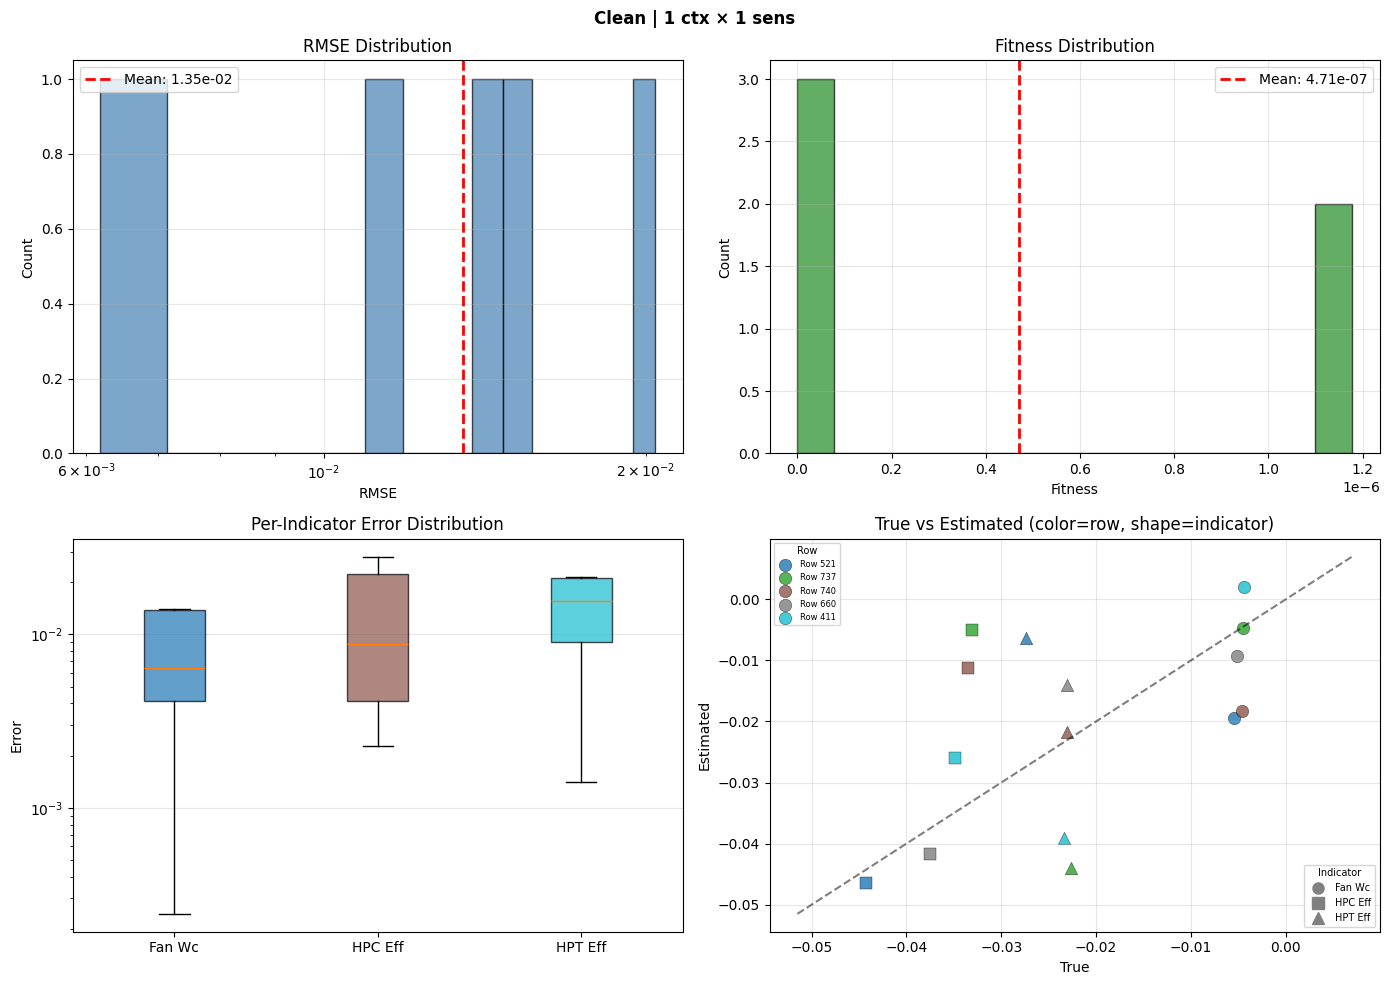

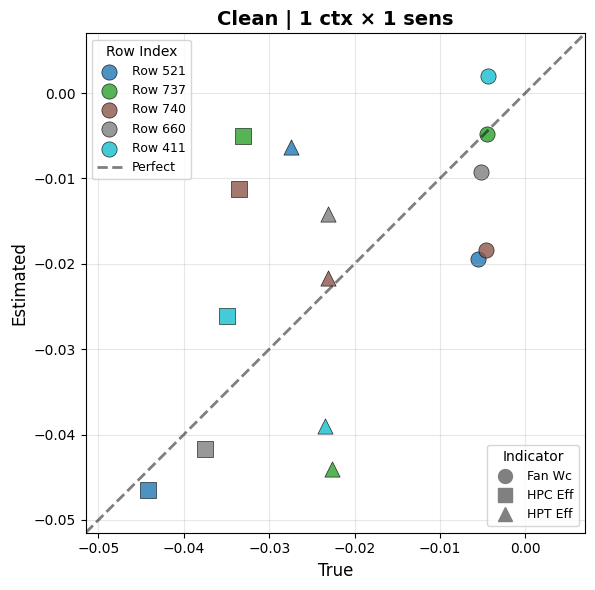

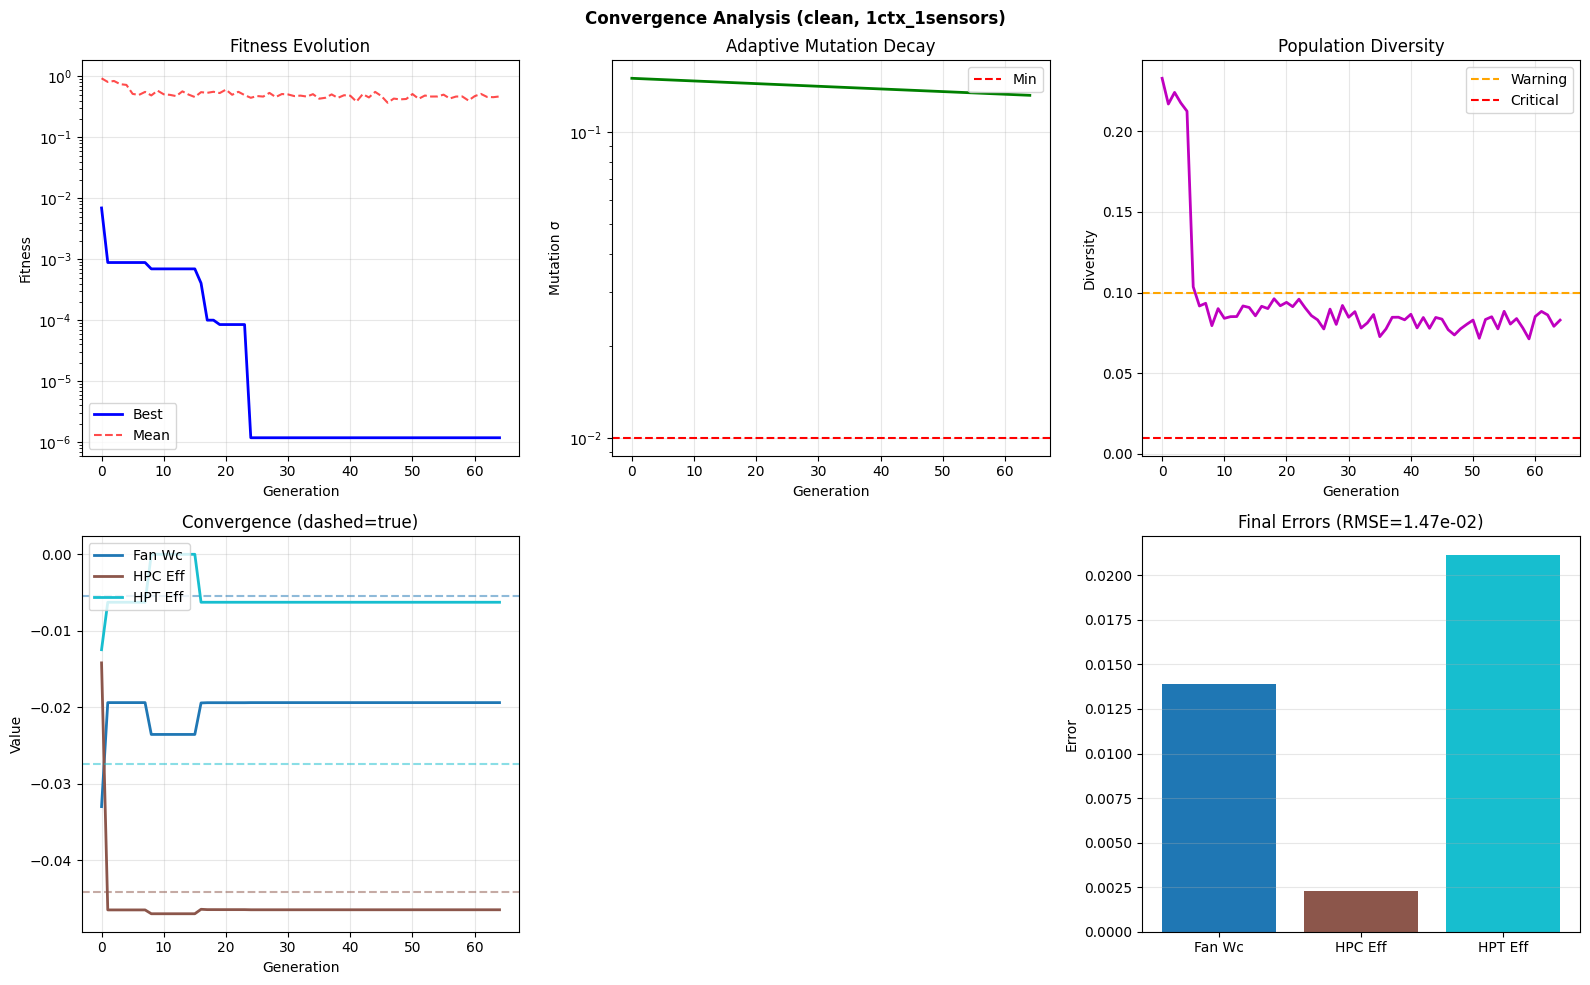

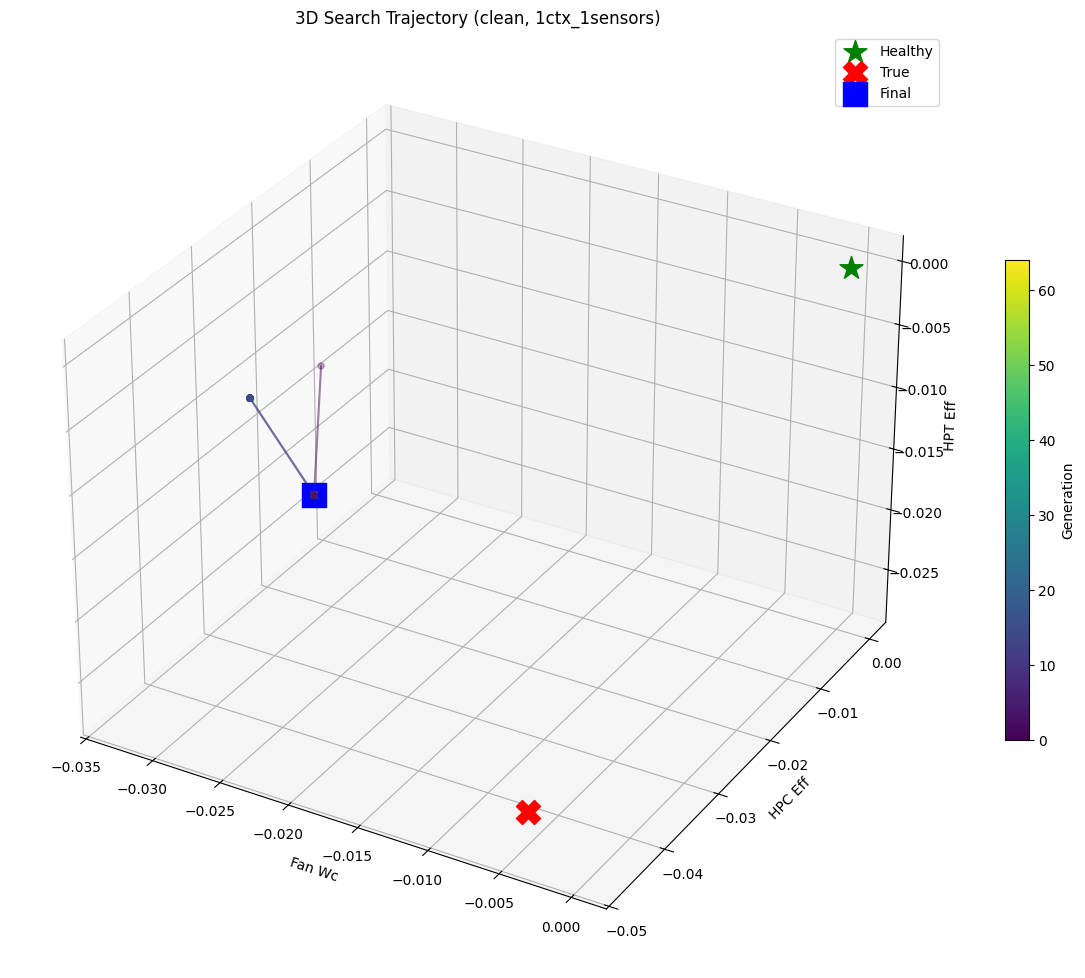

    Mean RMSE: 1.35e-02 ± 5.28e-03
    Mean Time: 1991.62s ± 498.43s

  1ctx_2sensors: ['CLIMB1'] × ['HPC_Tin', 'LPT_Tin']
    2 measurements → 3 indicators


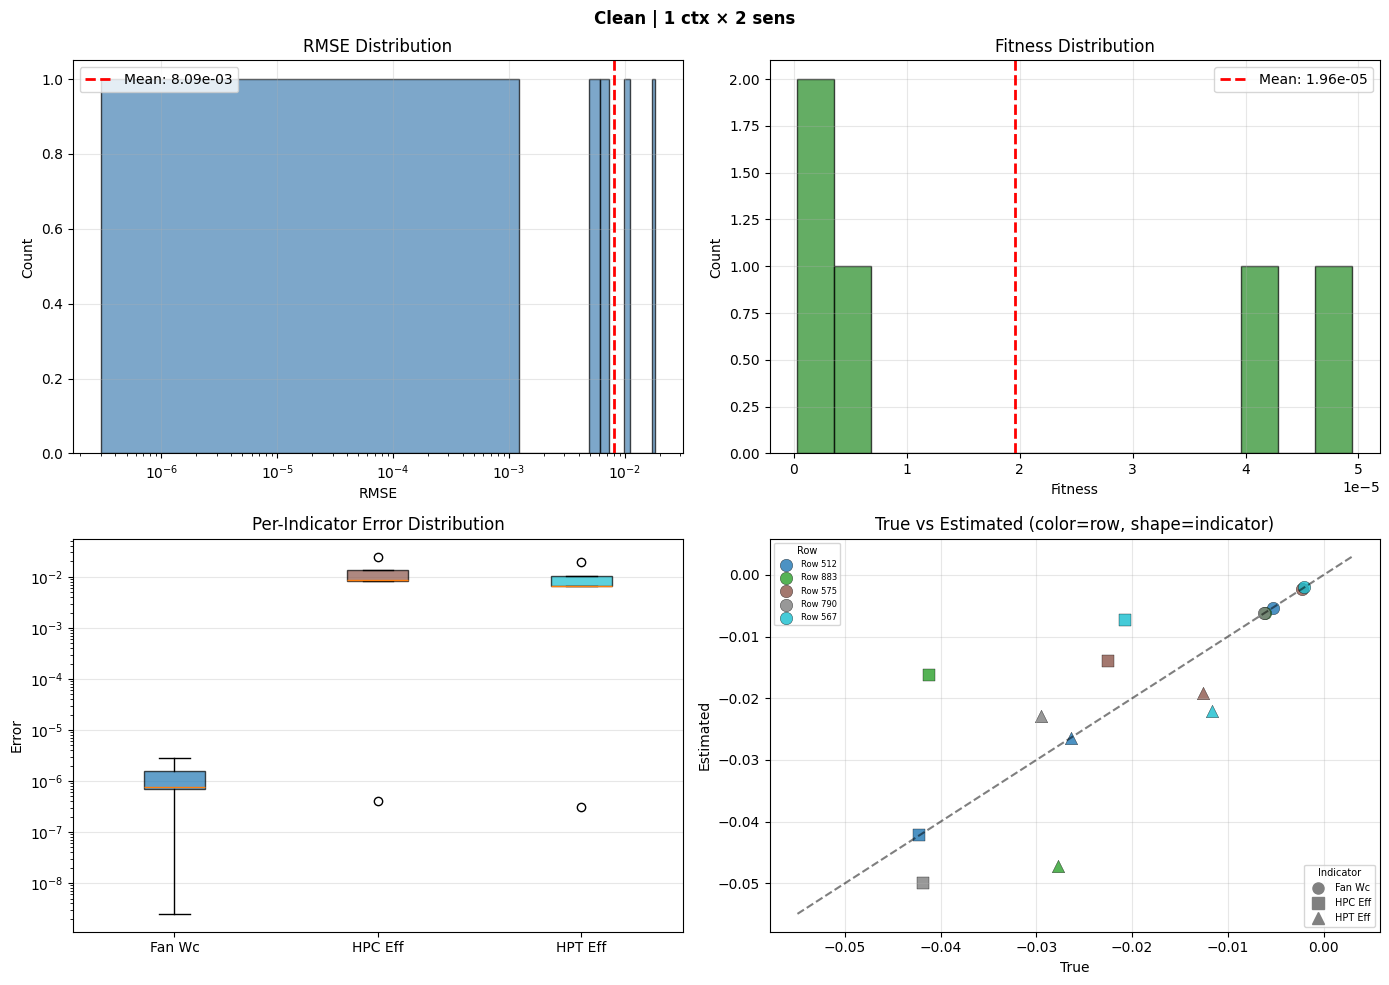

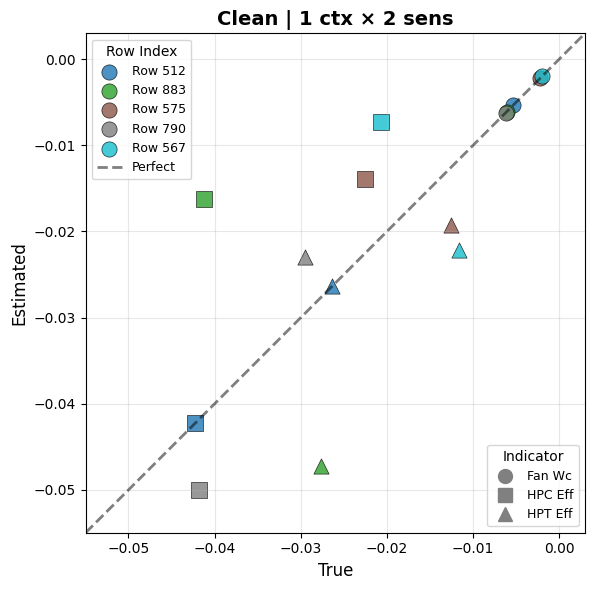

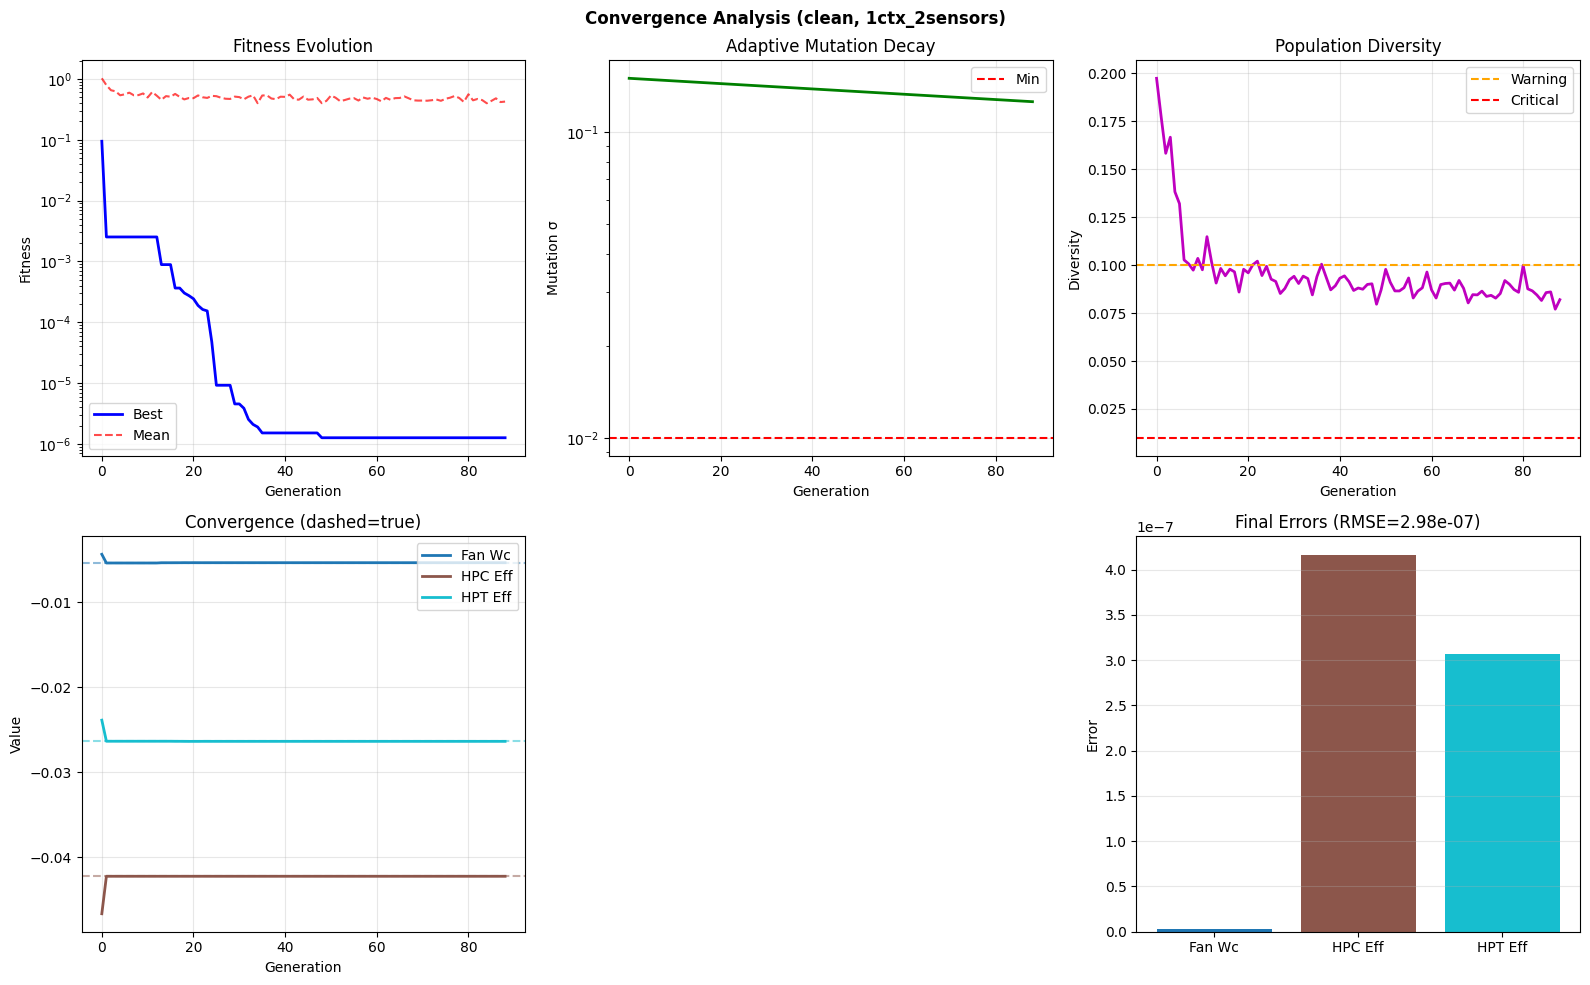

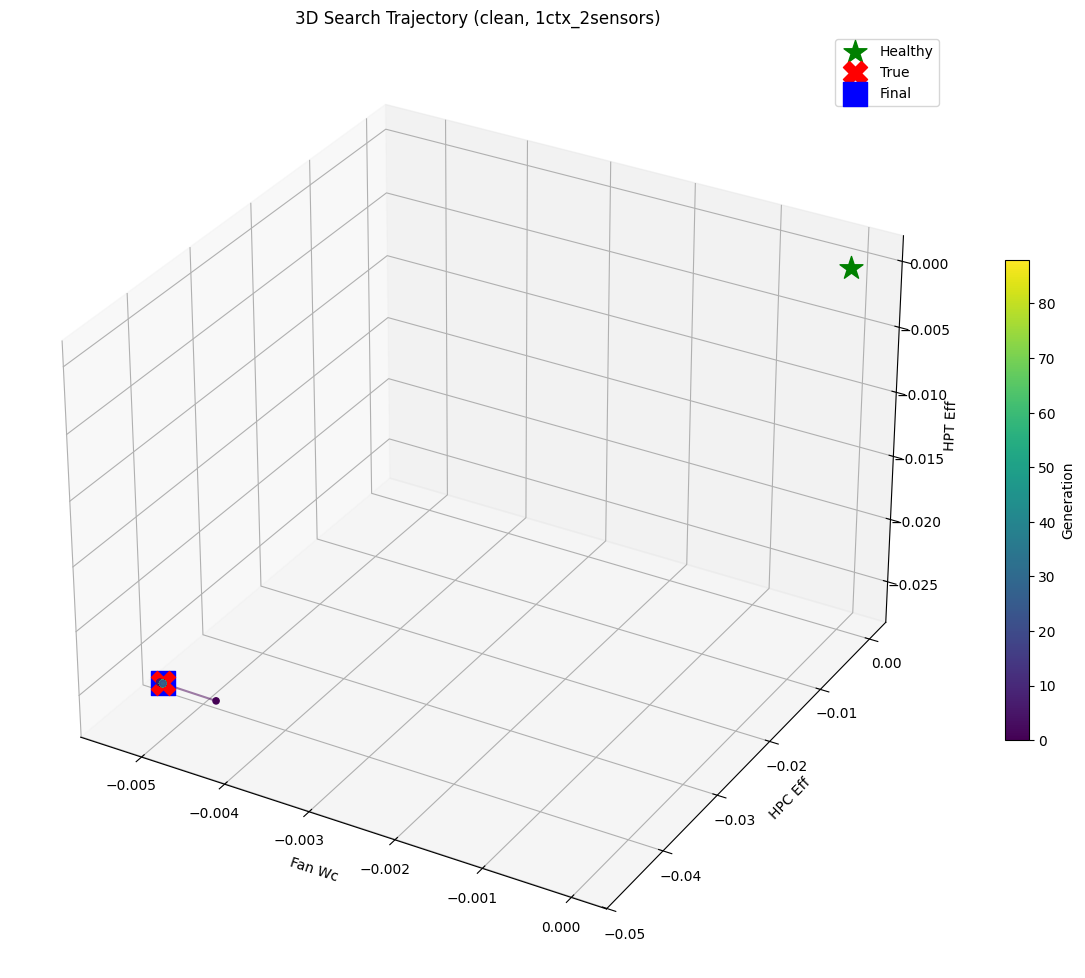

    Running ablation study...
Running BASELINE...
  RMSE: 1.82e-03

Sensor ablation:
  Without HPC_Tin... RMSE: 1.58e-02 (+769.6%)
  Without LPT_Tin... RMSE: 2.65e-02 (+1355.0%)


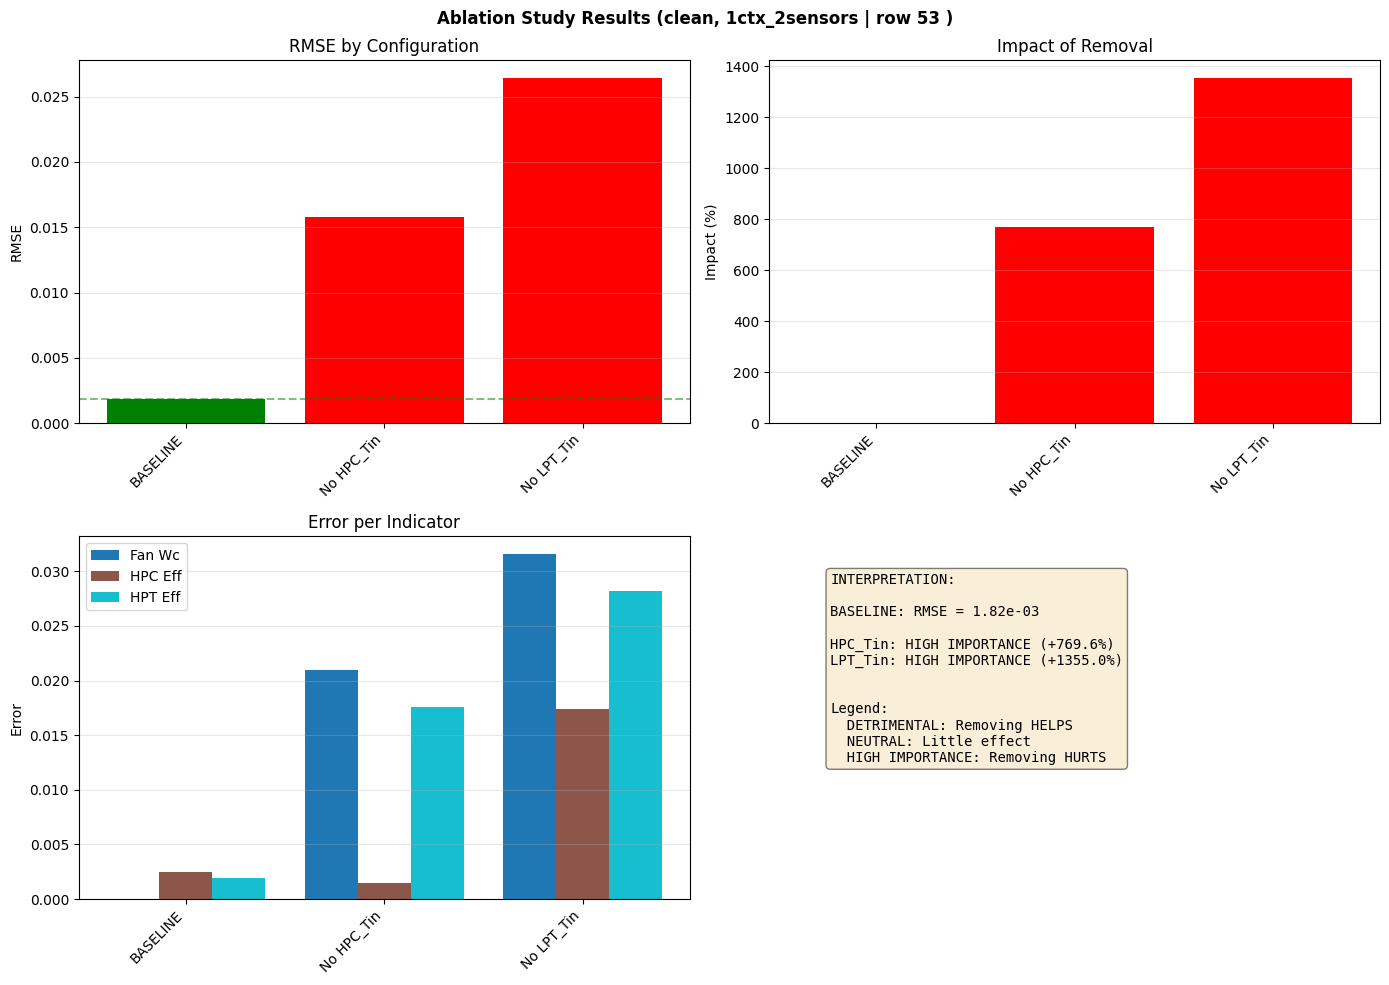

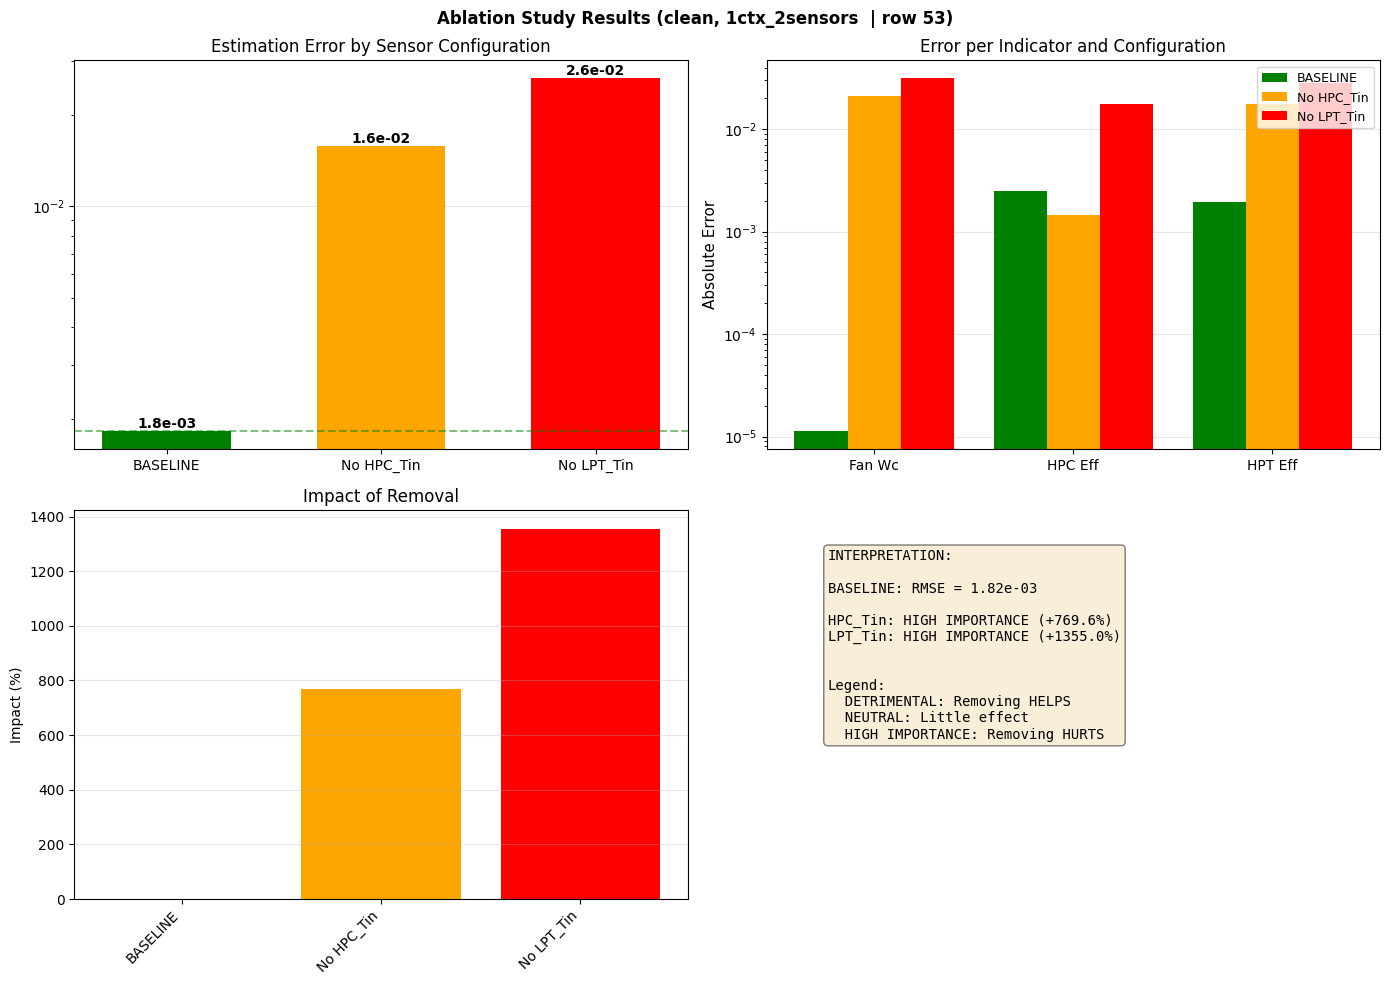

    Mean RMSE: 8.09e-03 ± 6.72e-03
    Mean Time: 2564.99s ± 443.71s

  1ctx_3sensors: ['CLIMB1'] × ['HPC_Tin', 'LPT_Tin', 'HPC_Pout_st']
    3 measurements → 3 indicators


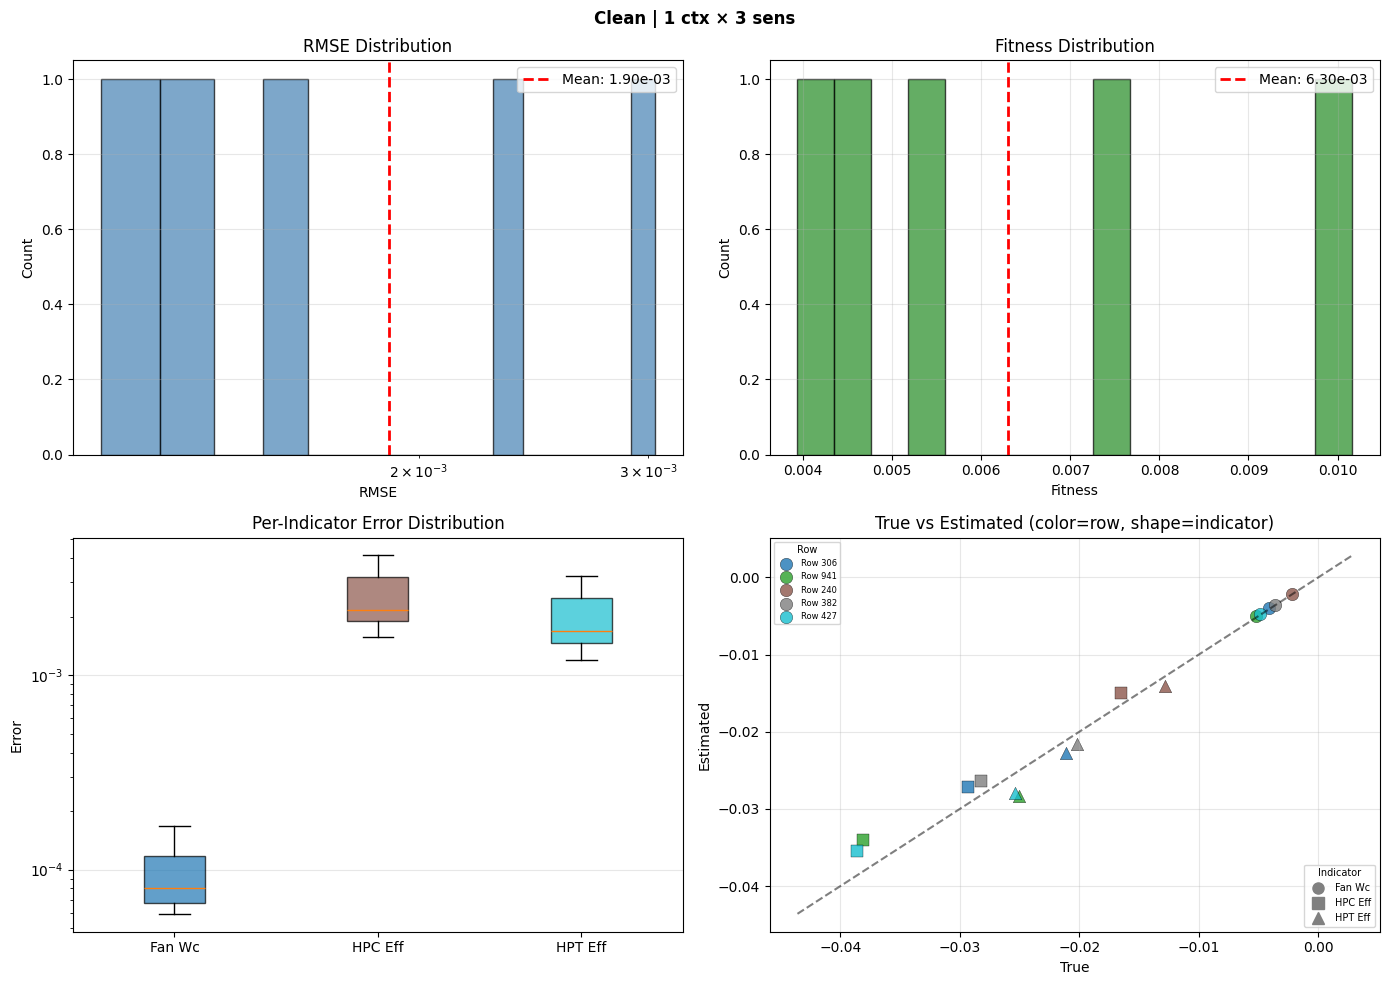

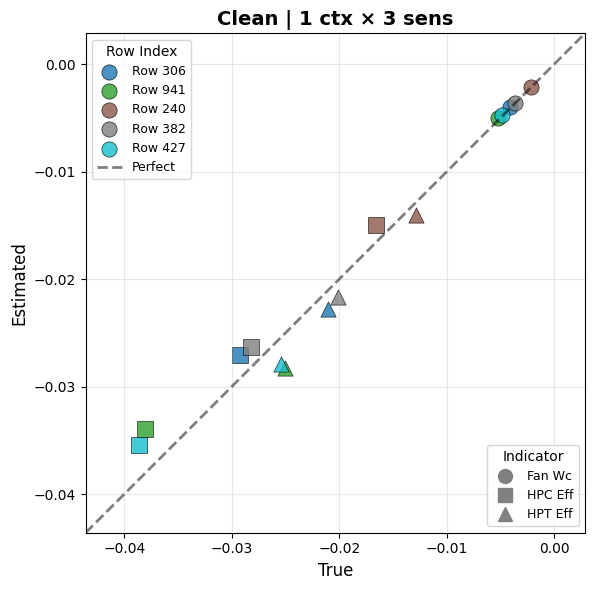

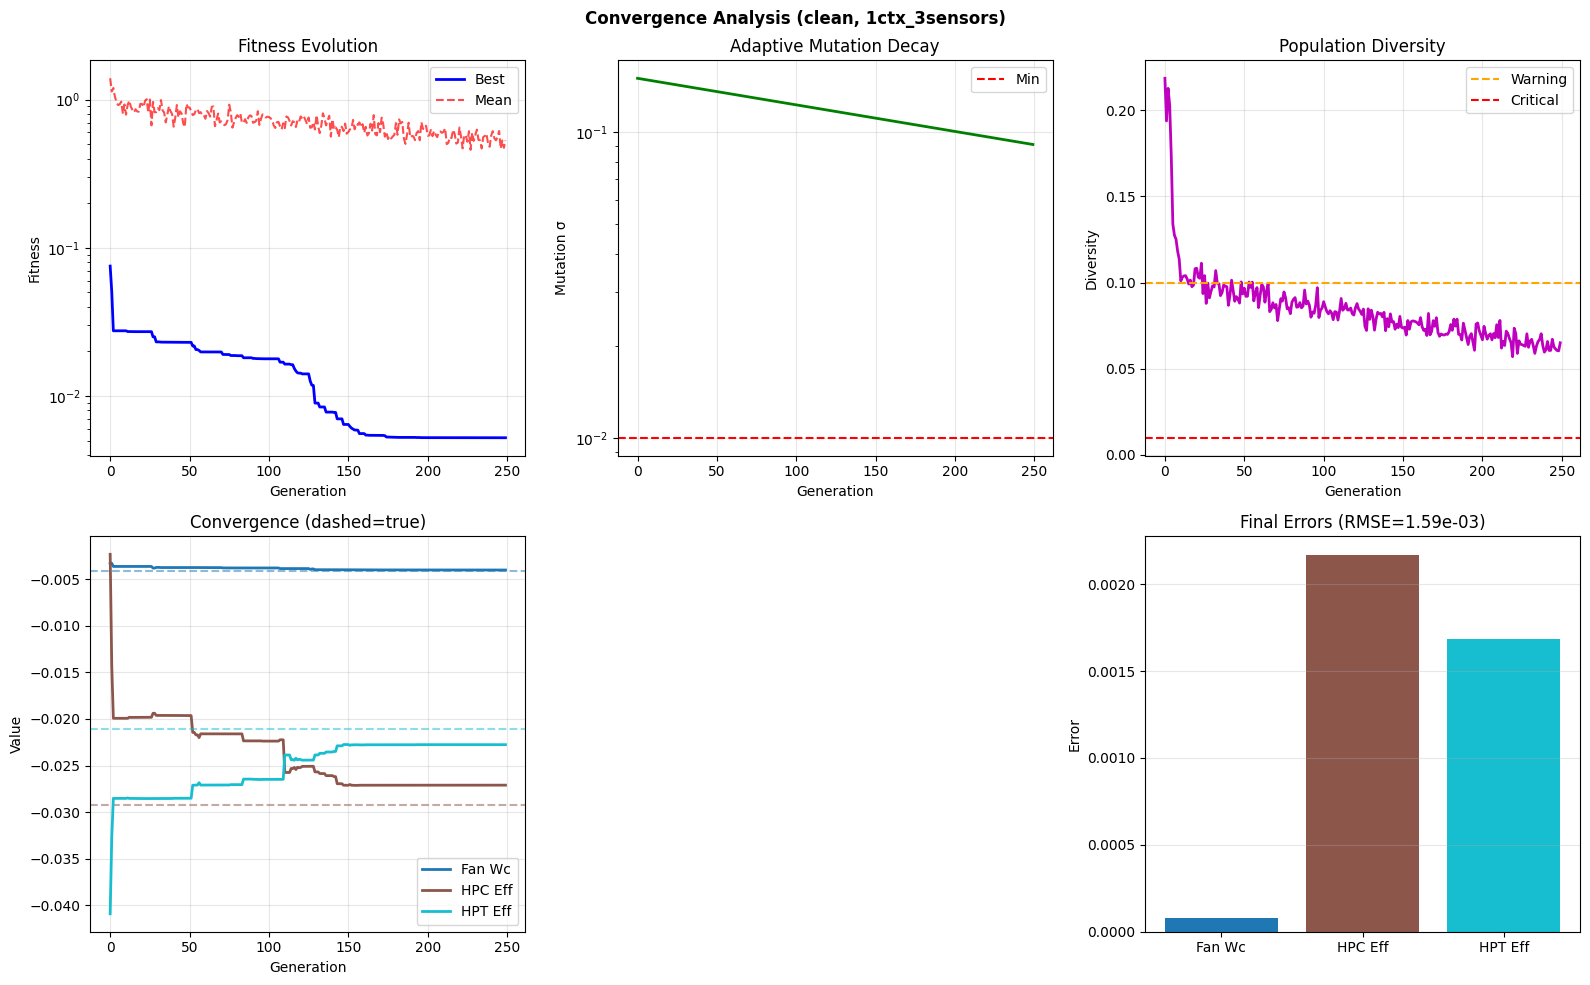

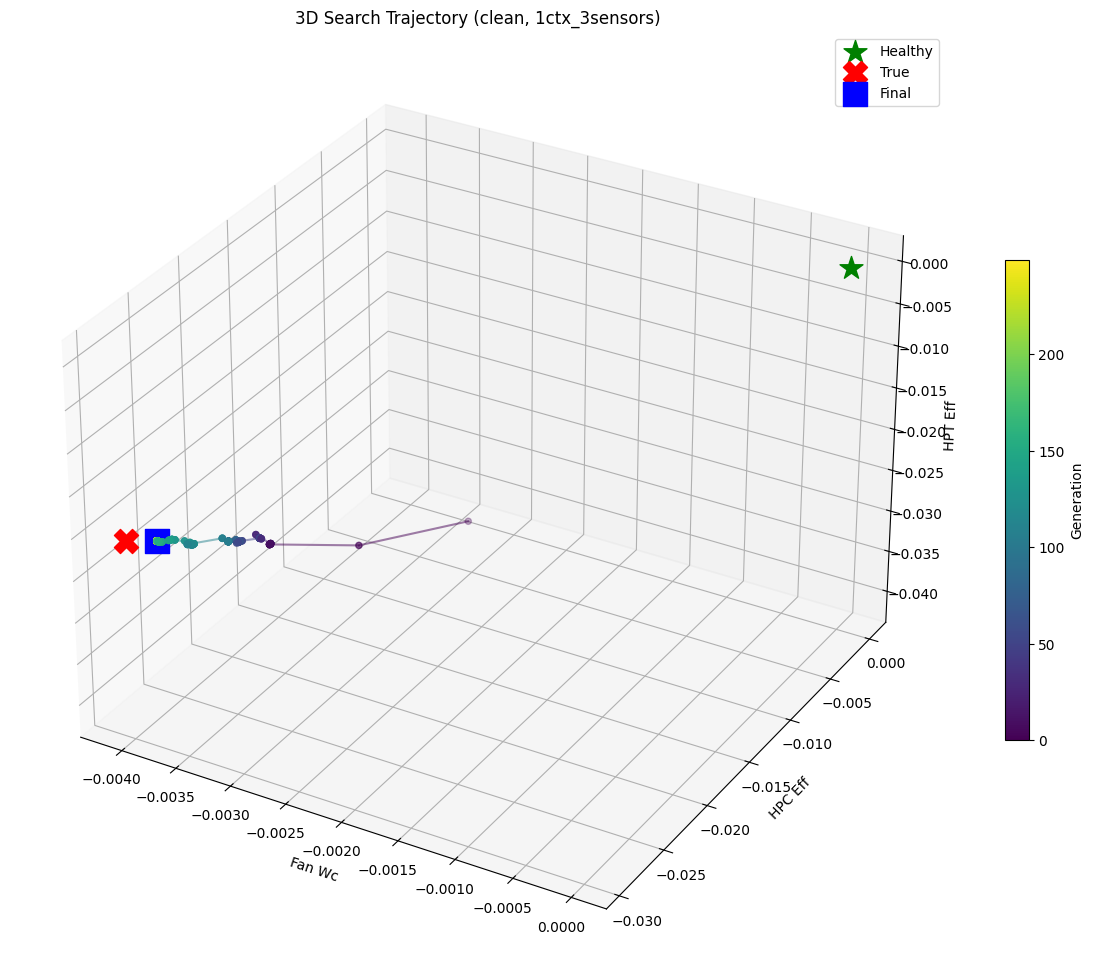

    Running ablation study...
Running BASELINE...
  RMSE: 1.65e-03

Sensor ablation:
  Without HPC_Tin... RMSE: 8.37e-03 (+406.3%)
  Without LPT_Tin... RMSE: 4.34e-03 (+162.5%)
  Without HPC_Pout_st... RMSE: 3.25e-03 (+96.5%)


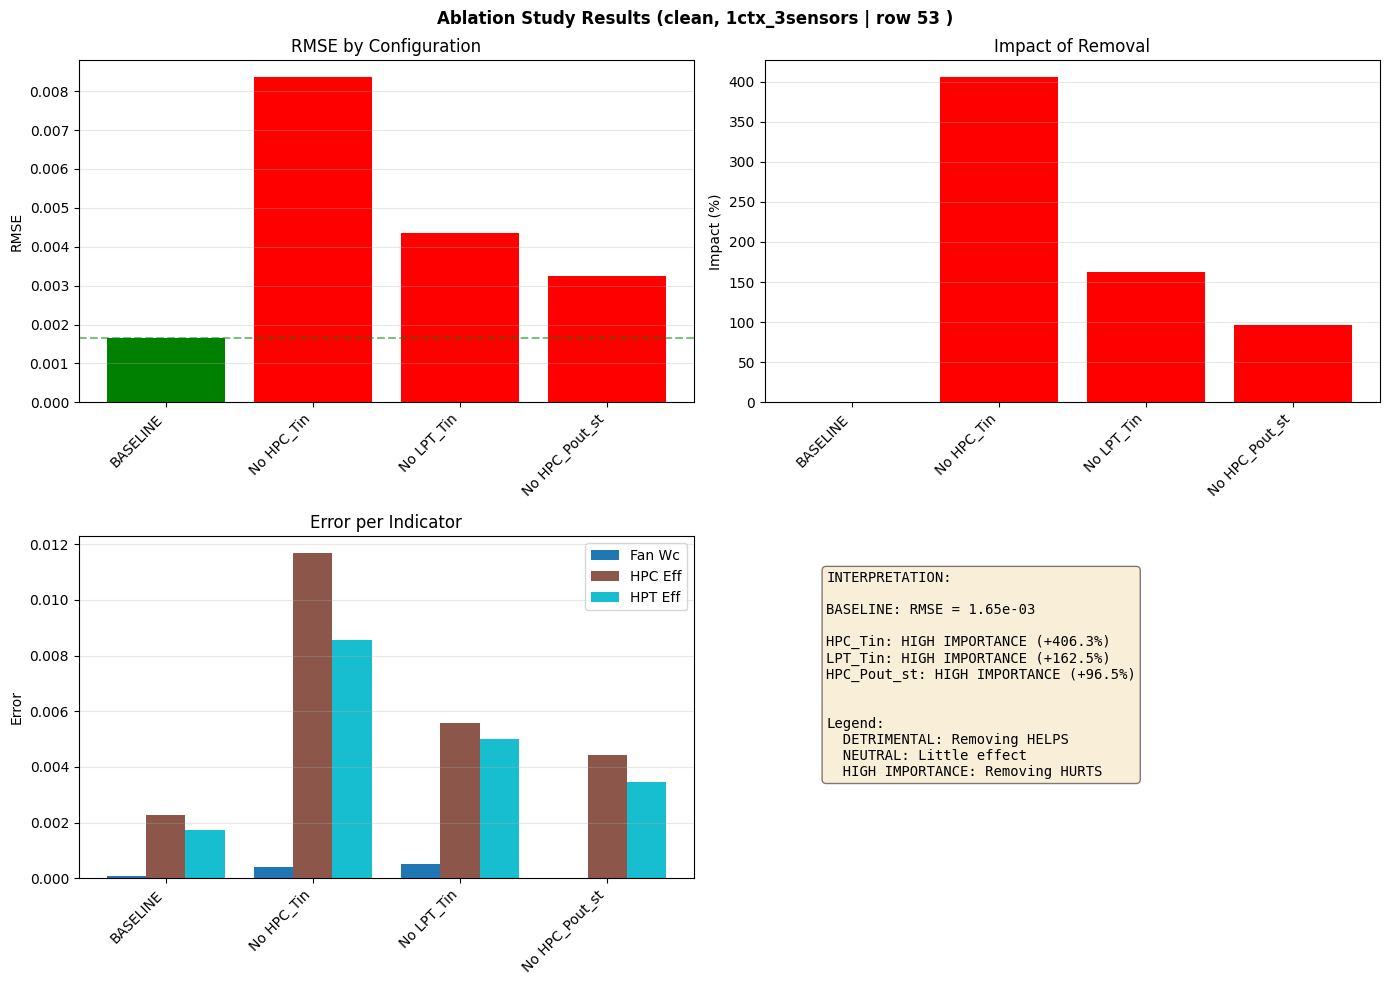

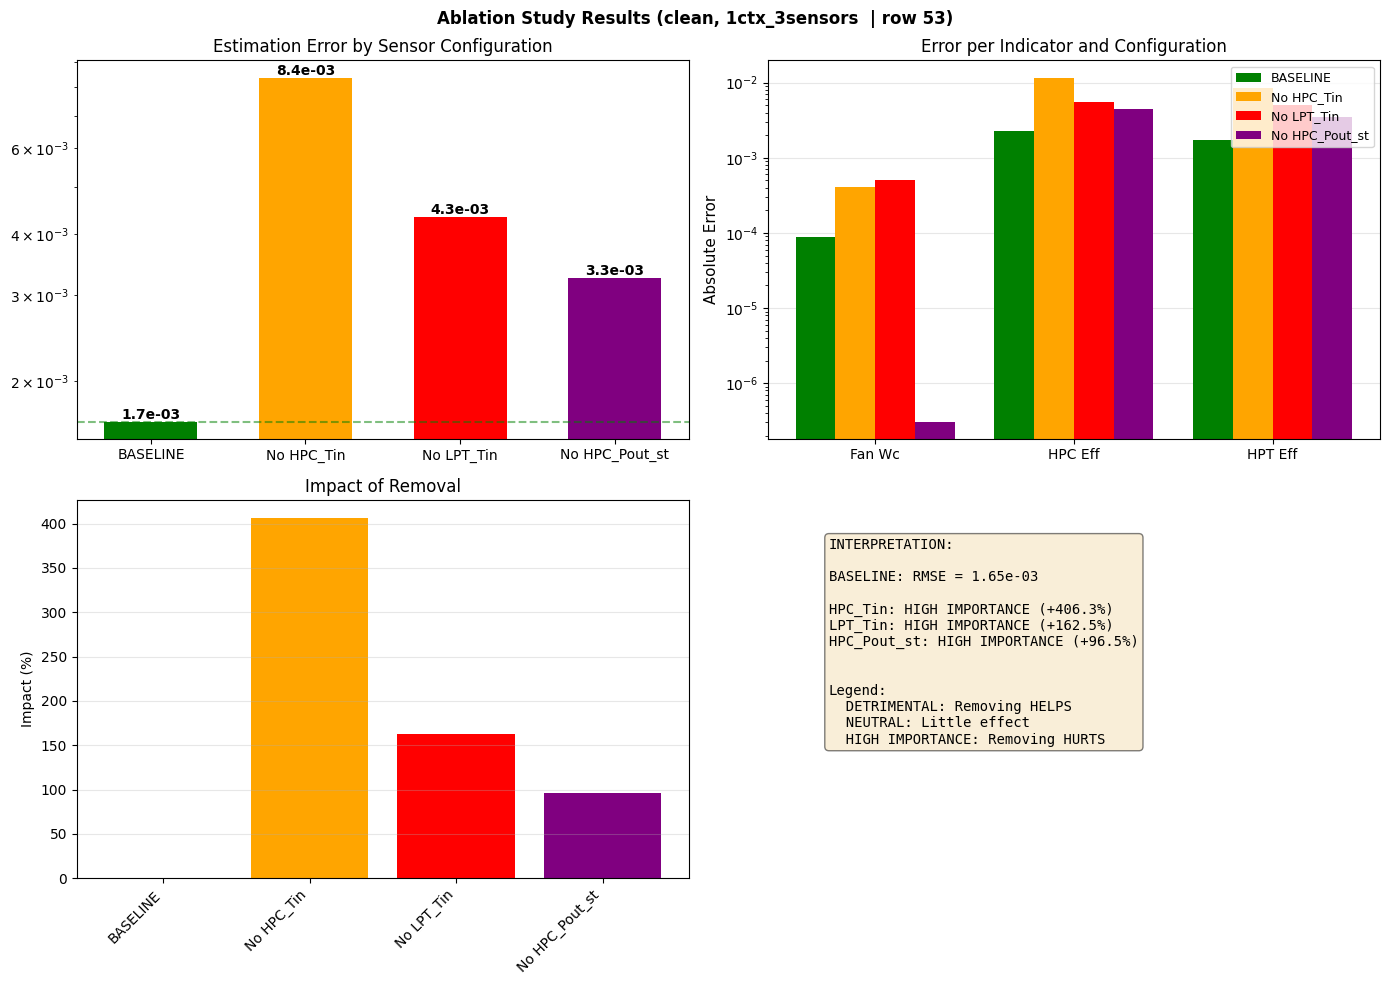

    Mean RMSE: 1.90e-03 ± 7.80e-04
    Mean Time: 5727.04s ± 2197.08s

Running experiments on NOISY data

  1ctx_1sensors: ['CLIMB1'] × ['HPC_Tin']
    1 measurements → 3 indicators


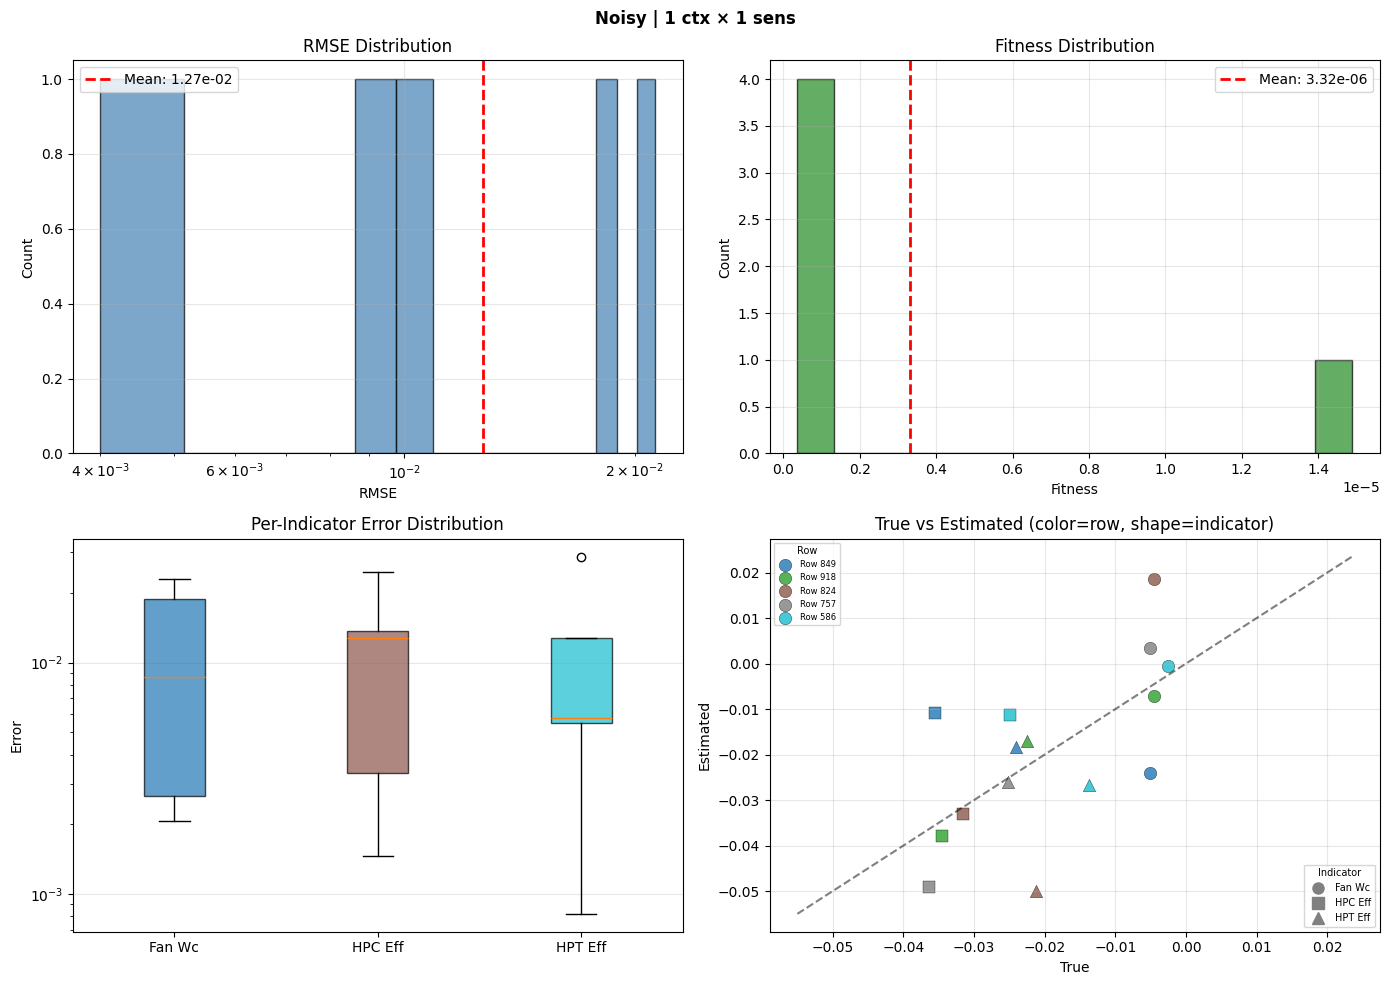

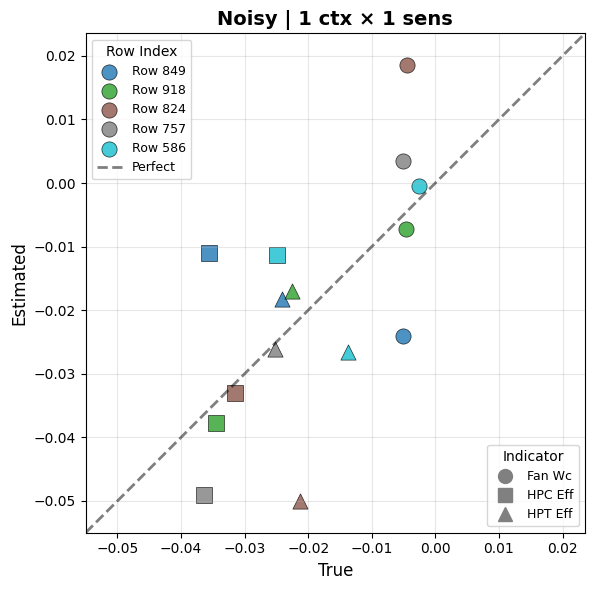

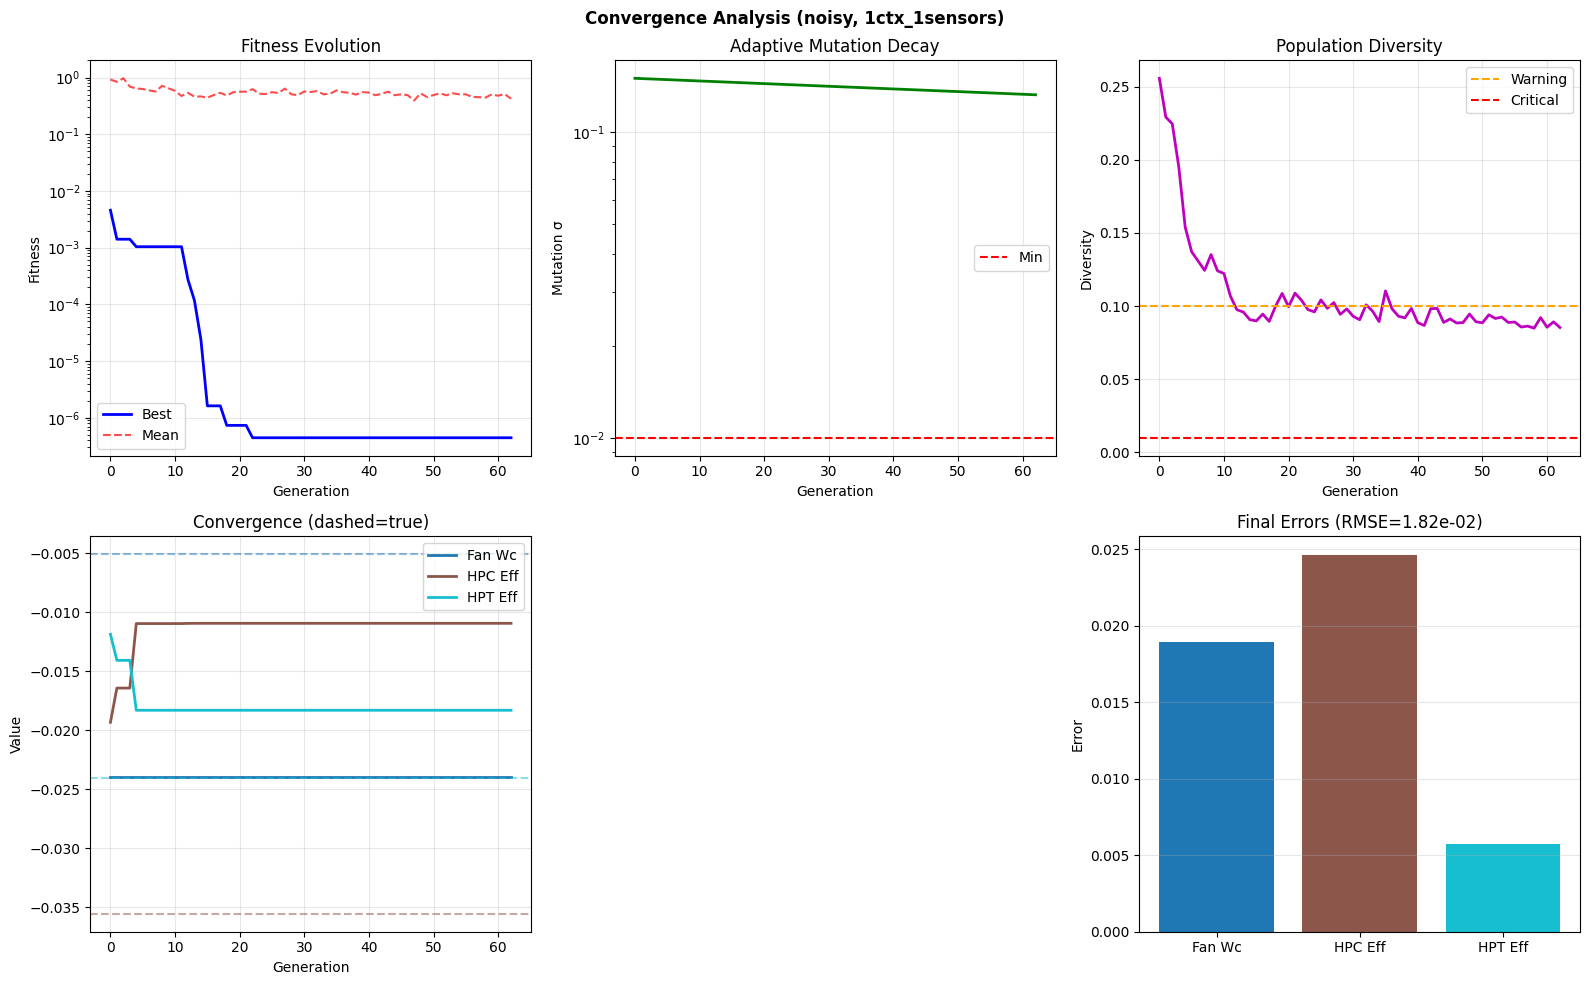

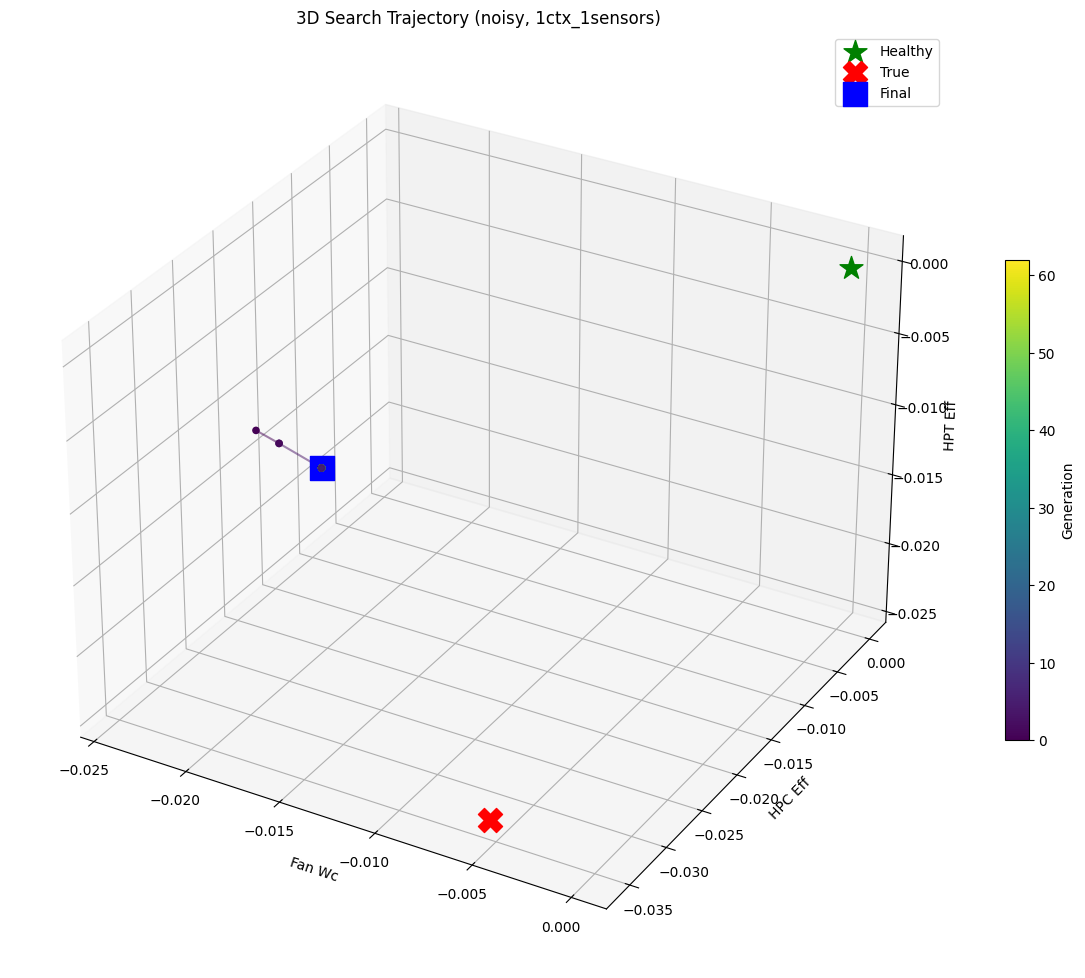

    Mean RMSE: 1.27e-02 ± 7.02e-03
    Mean Time: 1792.92s ± 220.00s

  1ctx_2sensors: ['CLIMB1'] × ['HPC_Tin', 'LPT_Tin']
    2 measurements → 3 indicators


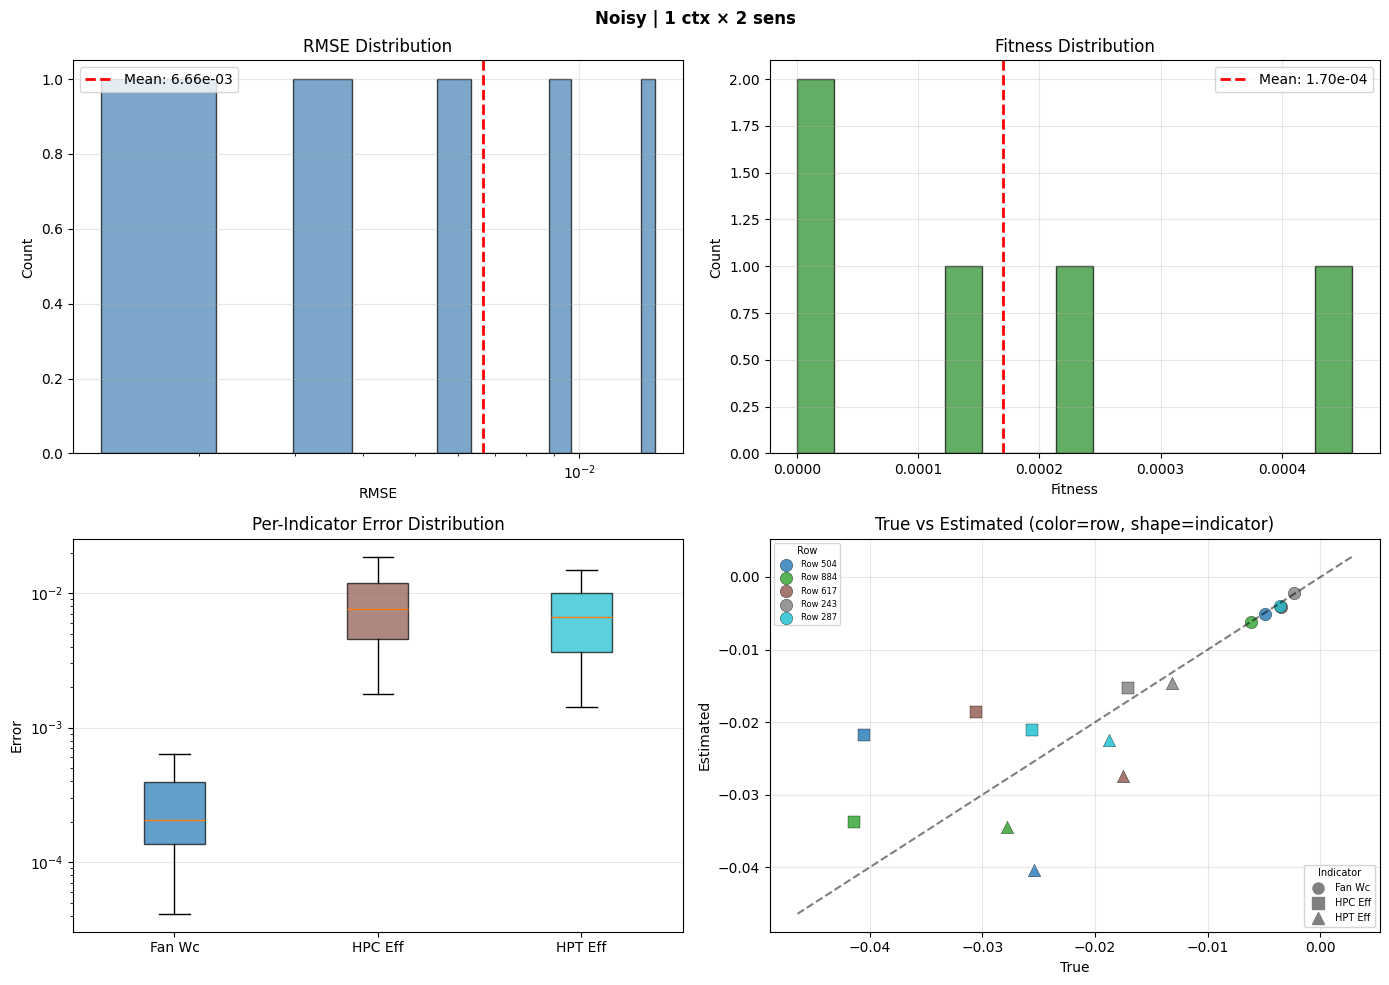

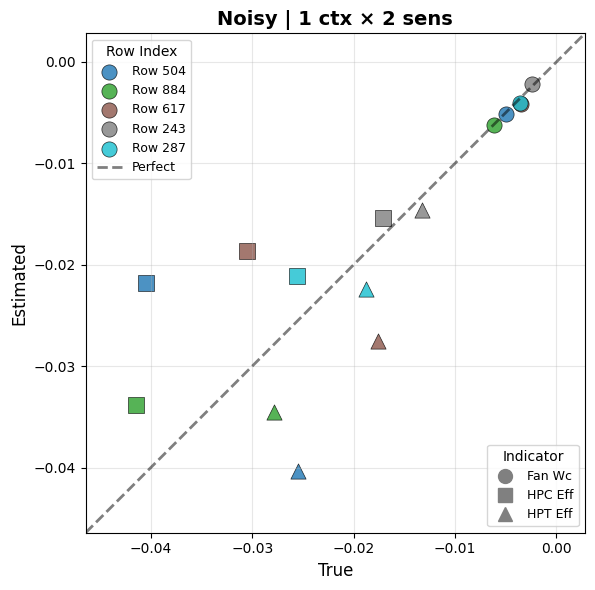

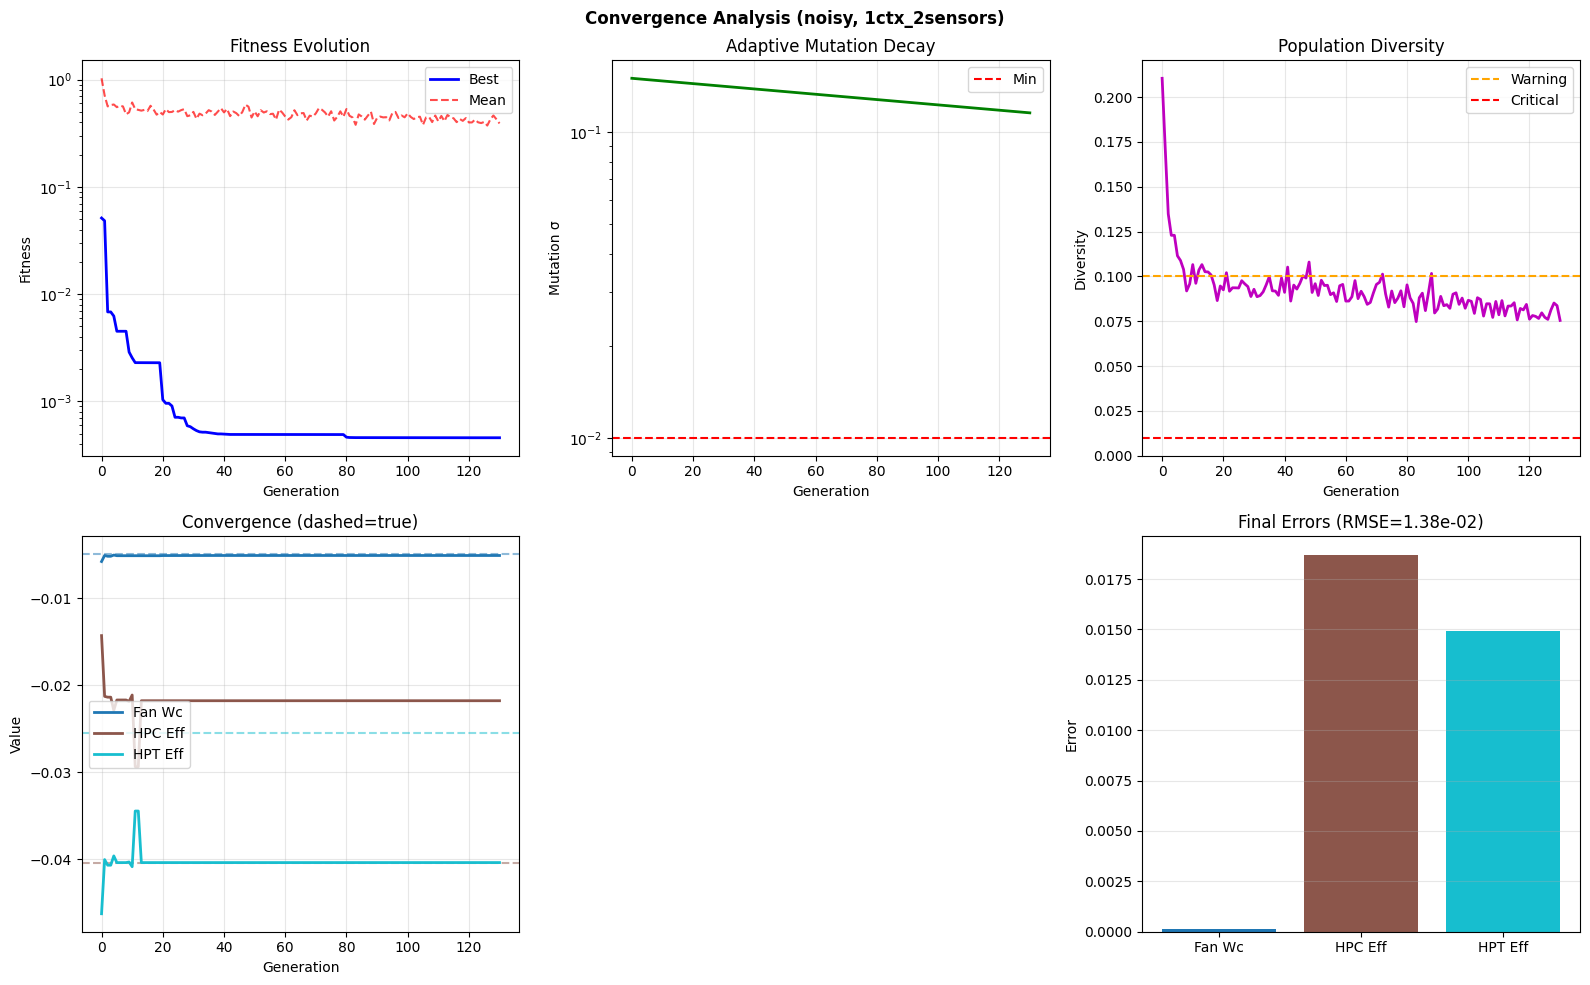

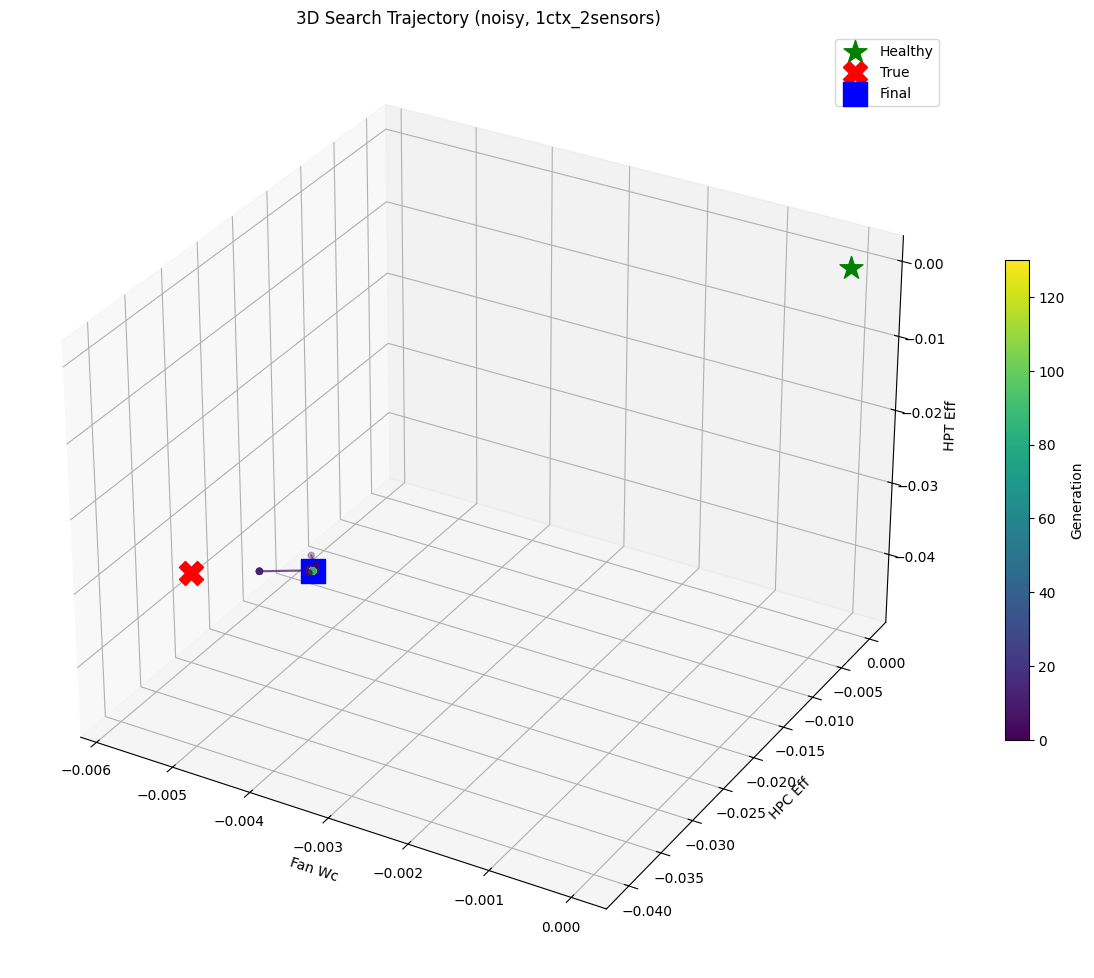

    Running ablation study...
Running BASELINE...
  RMSE: 2.35e-04

Sensor ablation:
  Without HPC_Tin... RMSE: 2.47e-02 (+10413.6%)
  Without LPT_Tin... RMSE: 1.01e-02 (+4198.7%)


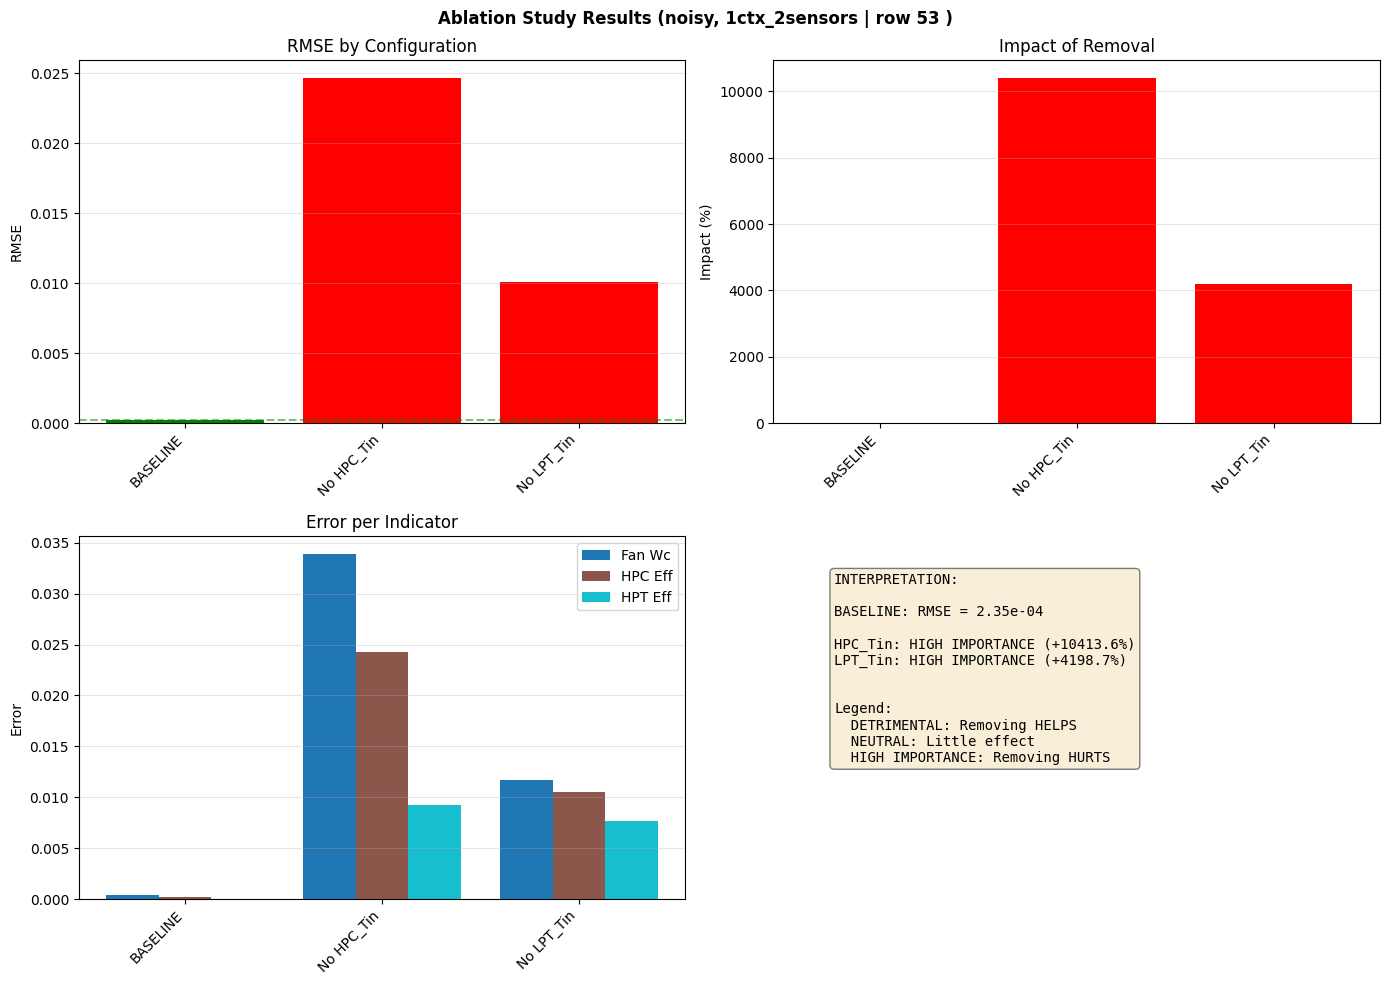

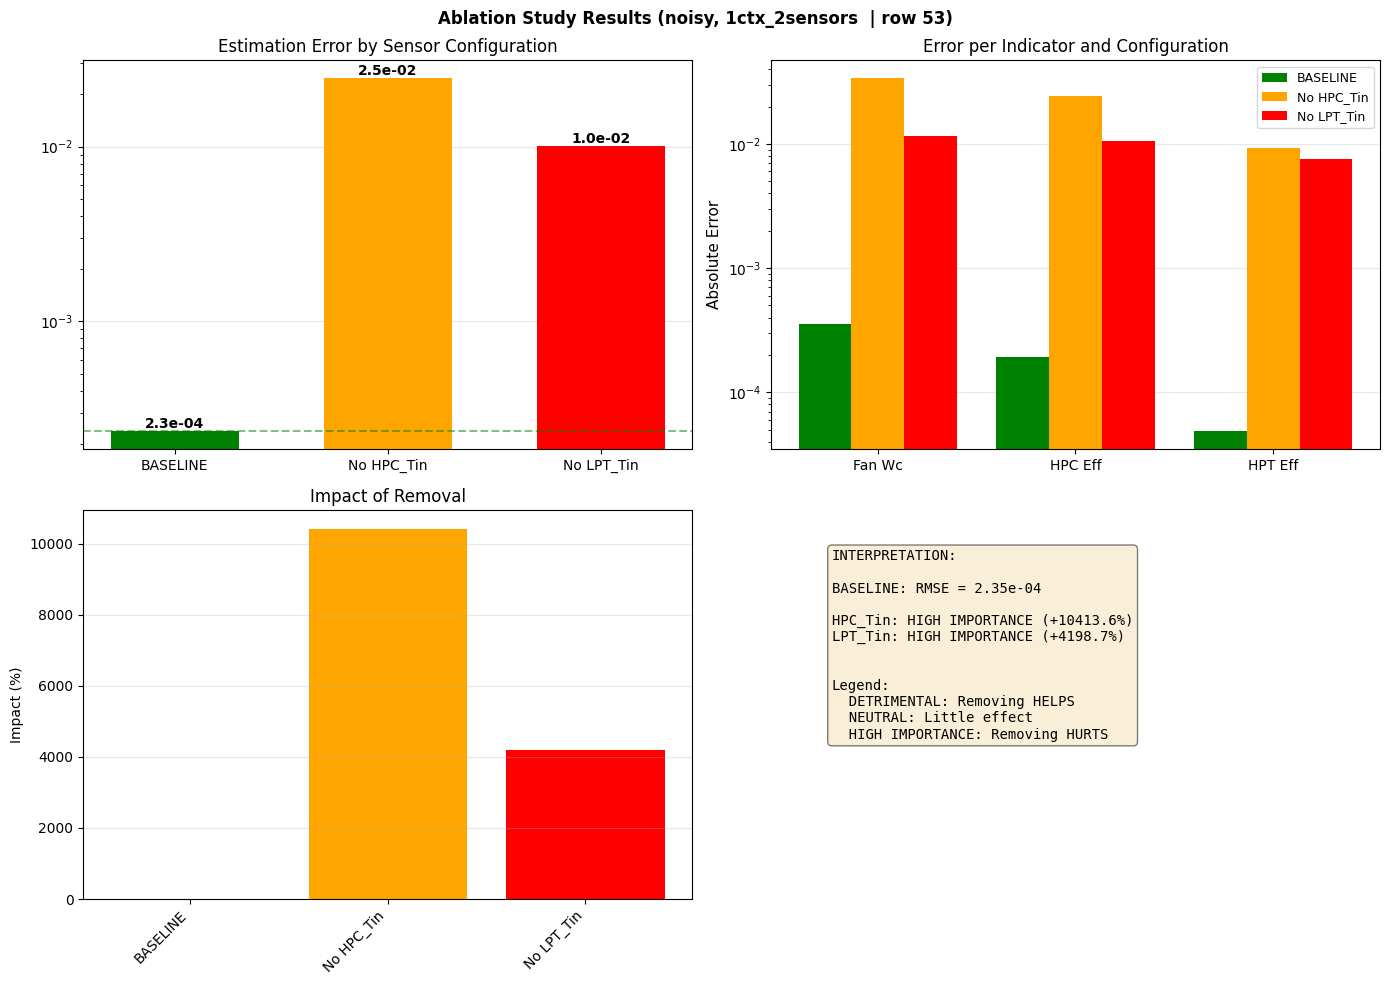

    Mean RMSE: 6.66e-03 ± 4.91e-03
    Mean Time: 2829.00s ± 552.30s

  1ctx_3sensors: ['CLIMB1'] × ['HPC_Tin', 'LPT_Tin', 'HPC_Pout_st']
    3 measurements → 3 indicators


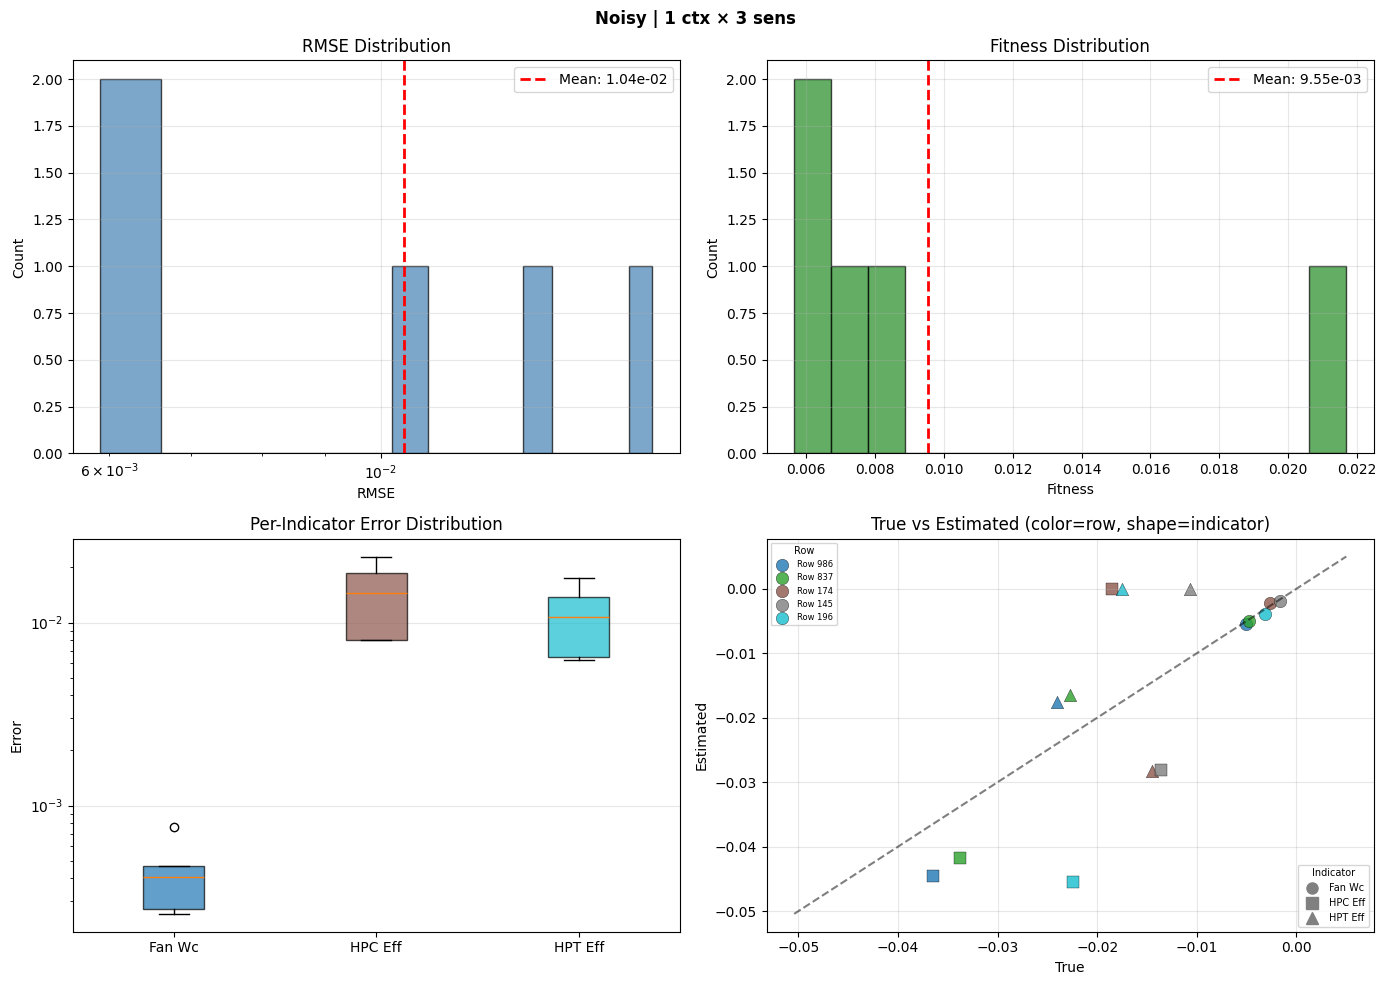

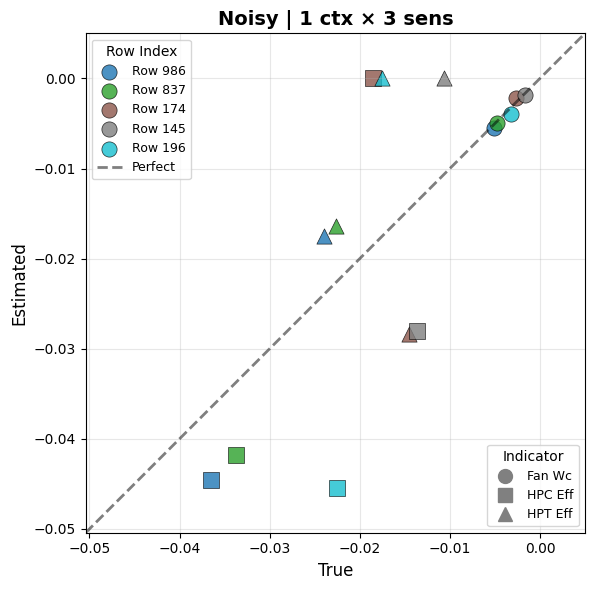

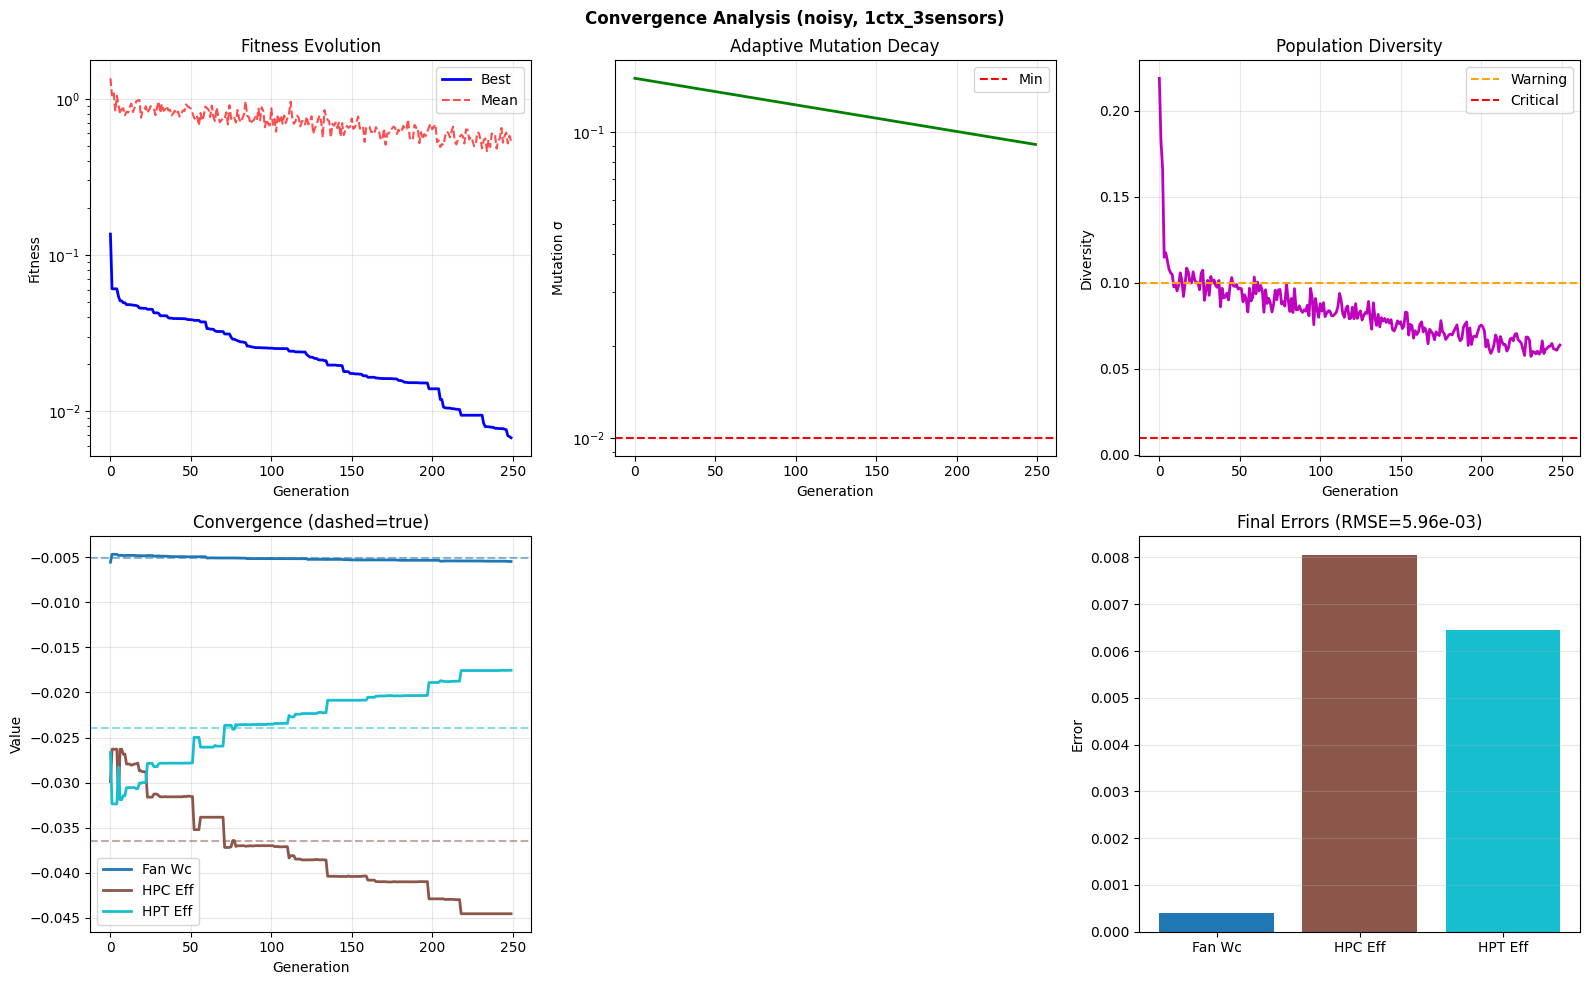

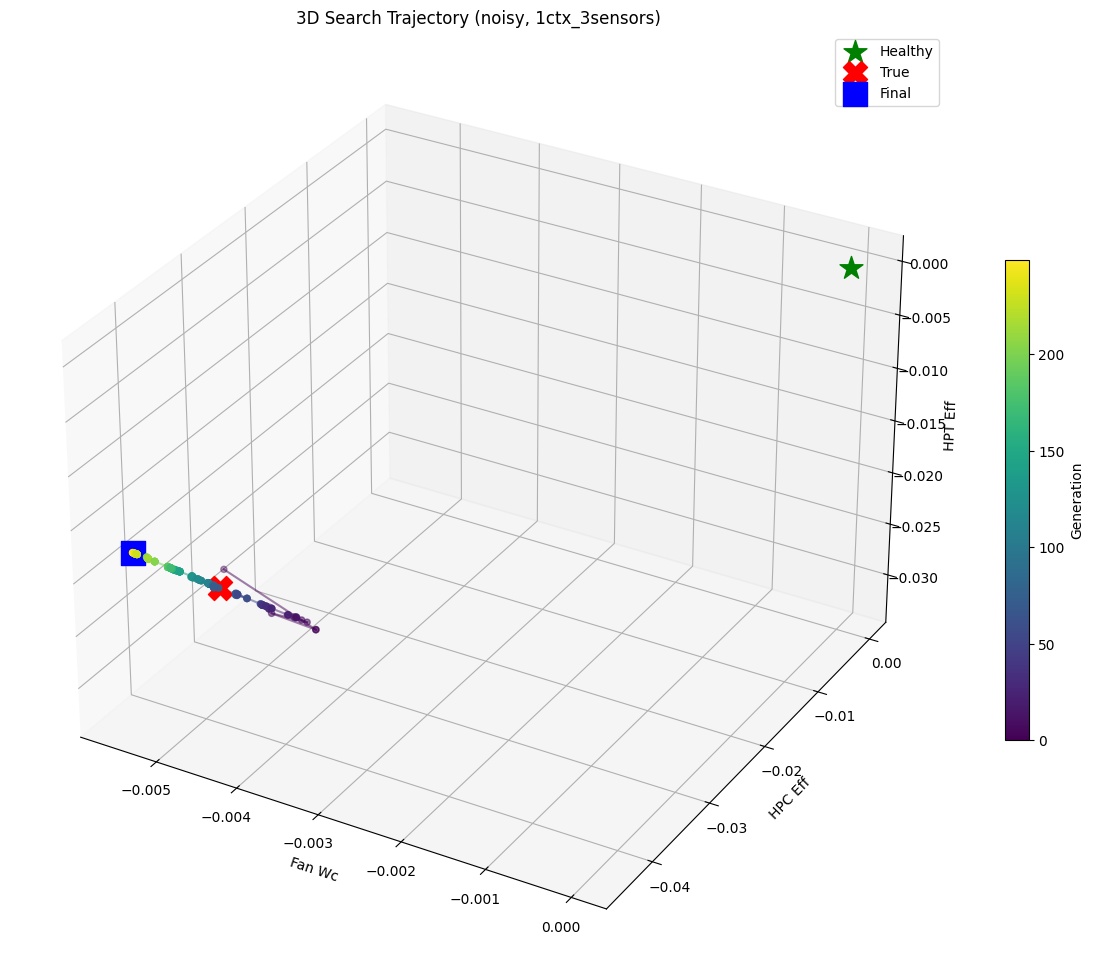

    Running ablation study...
Running BASELINE...
  RMSE: 1.19e-03

Sensor ablation:
  Without HPC_Tin... RMSE: 8.59e-03 (+620.9%)
  Without LPT_Tin... RMSE: 4.45e-03 (+273.5%)
  Without HPC_Pout_st... RMSE: 3.64e-03 (+205.6%)


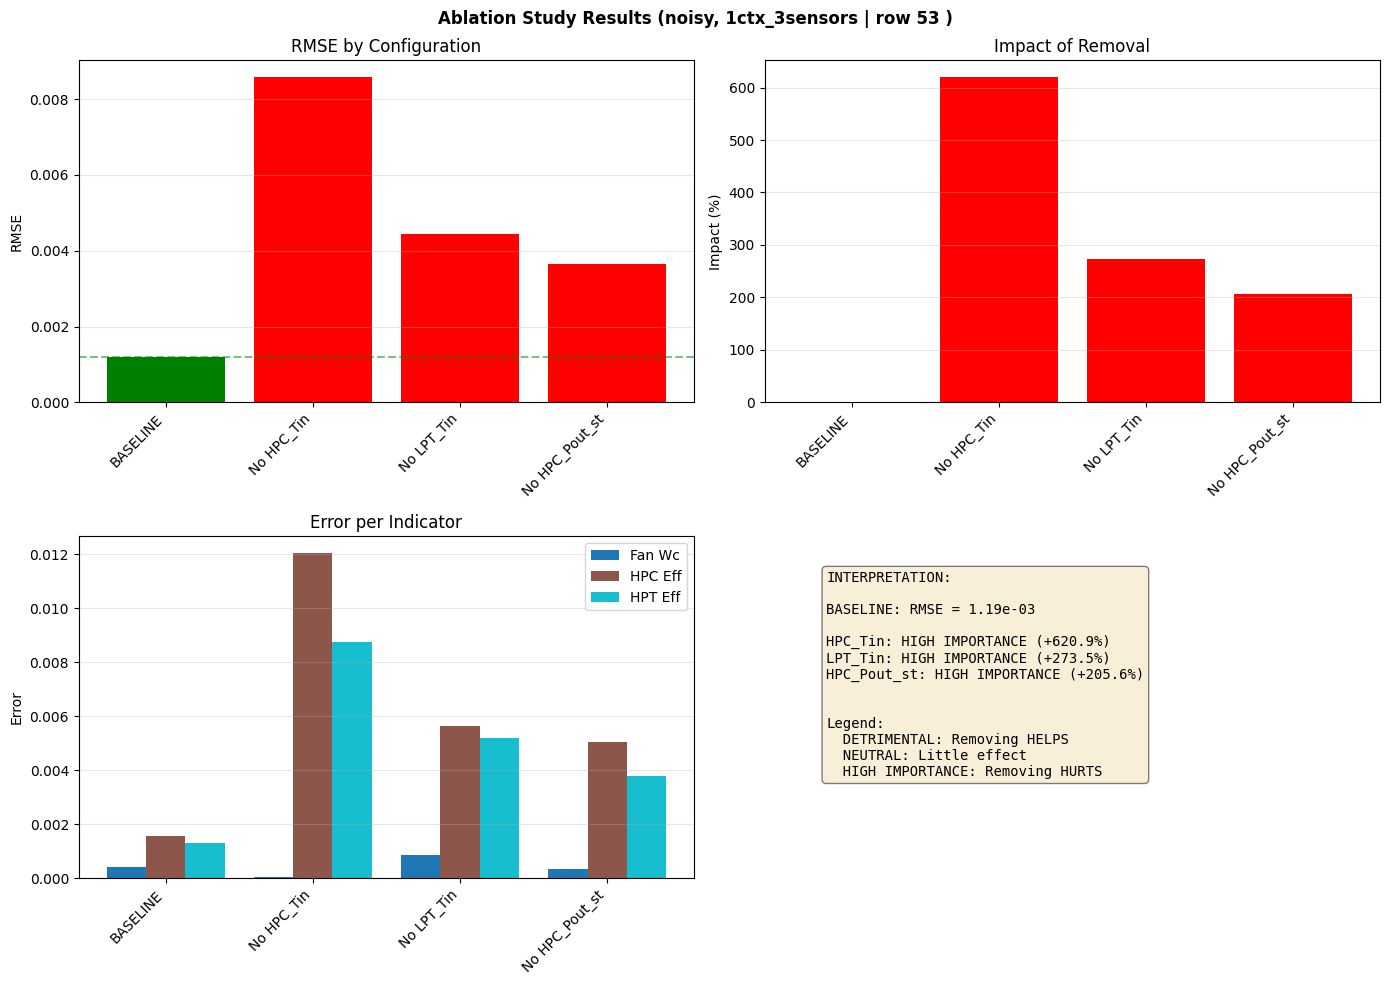

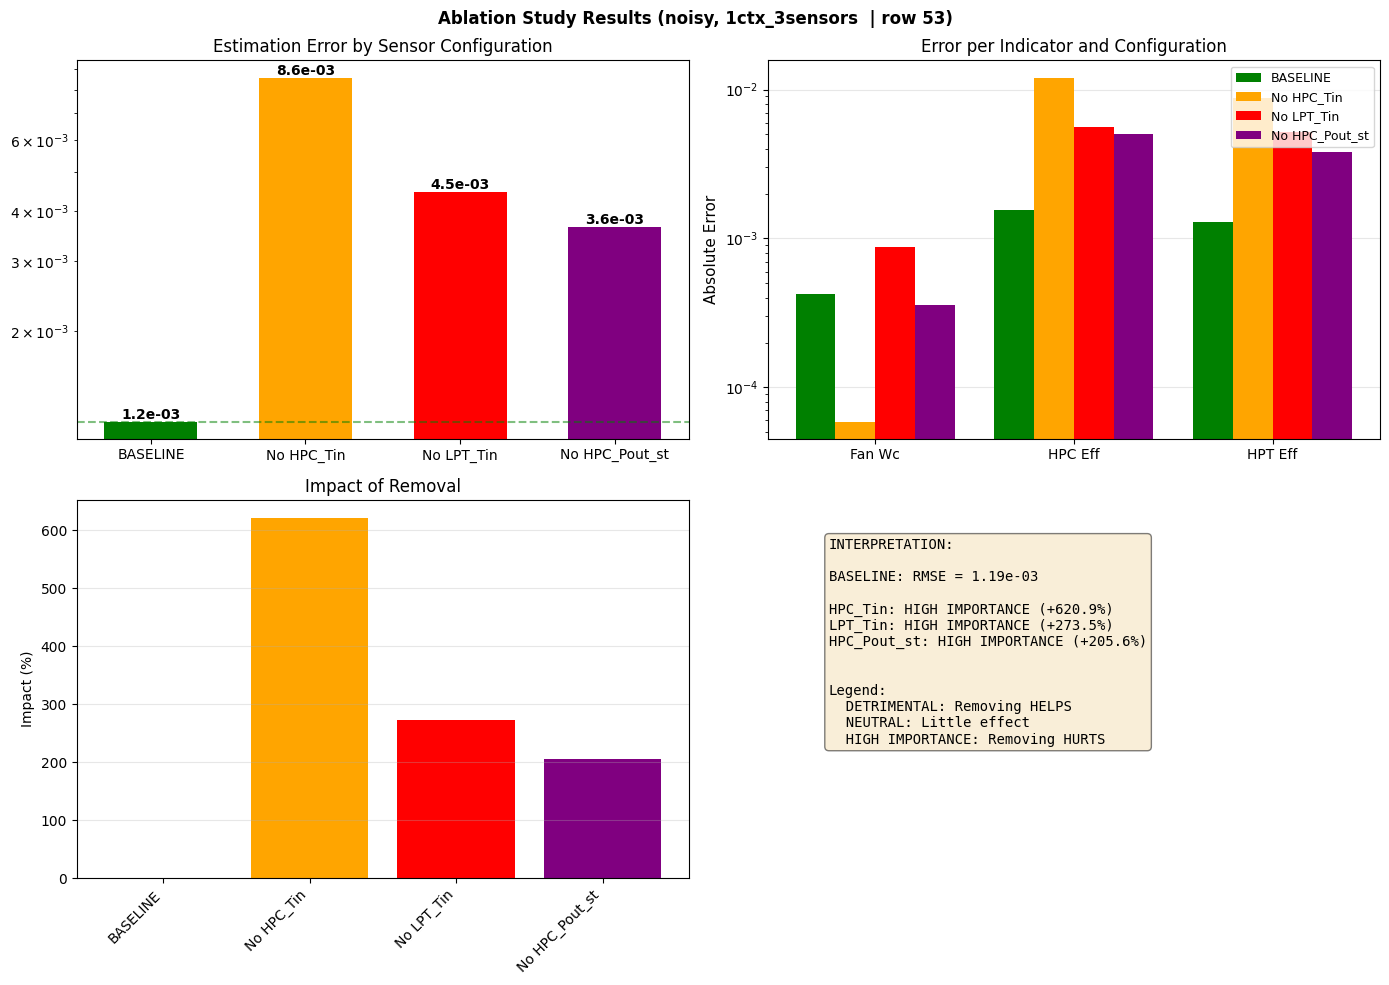

    Mean RMSE: 1.04e-02 ± 4.69e-03
    Mean Time: 4887.99s ± 1976.38s
CPU times: user 1h 51s, sys: 1min 40s, total: 1h 2min 31s
Wall time: 1d 14h 41min 30s


In [17]:
%%time
# Run all experiments
output_dir, summary_df = run_all_experiments(
    df_clean=df_clean,
    df_noisy=df_noisy,
    n_test_rows=N_TEST_ROWS,
    row_to_use =ROW_TO_USE ,
    
    output_base_dir=OUTPUT_BASE_DIR
)

---
## 4. Summary Comparison Plot

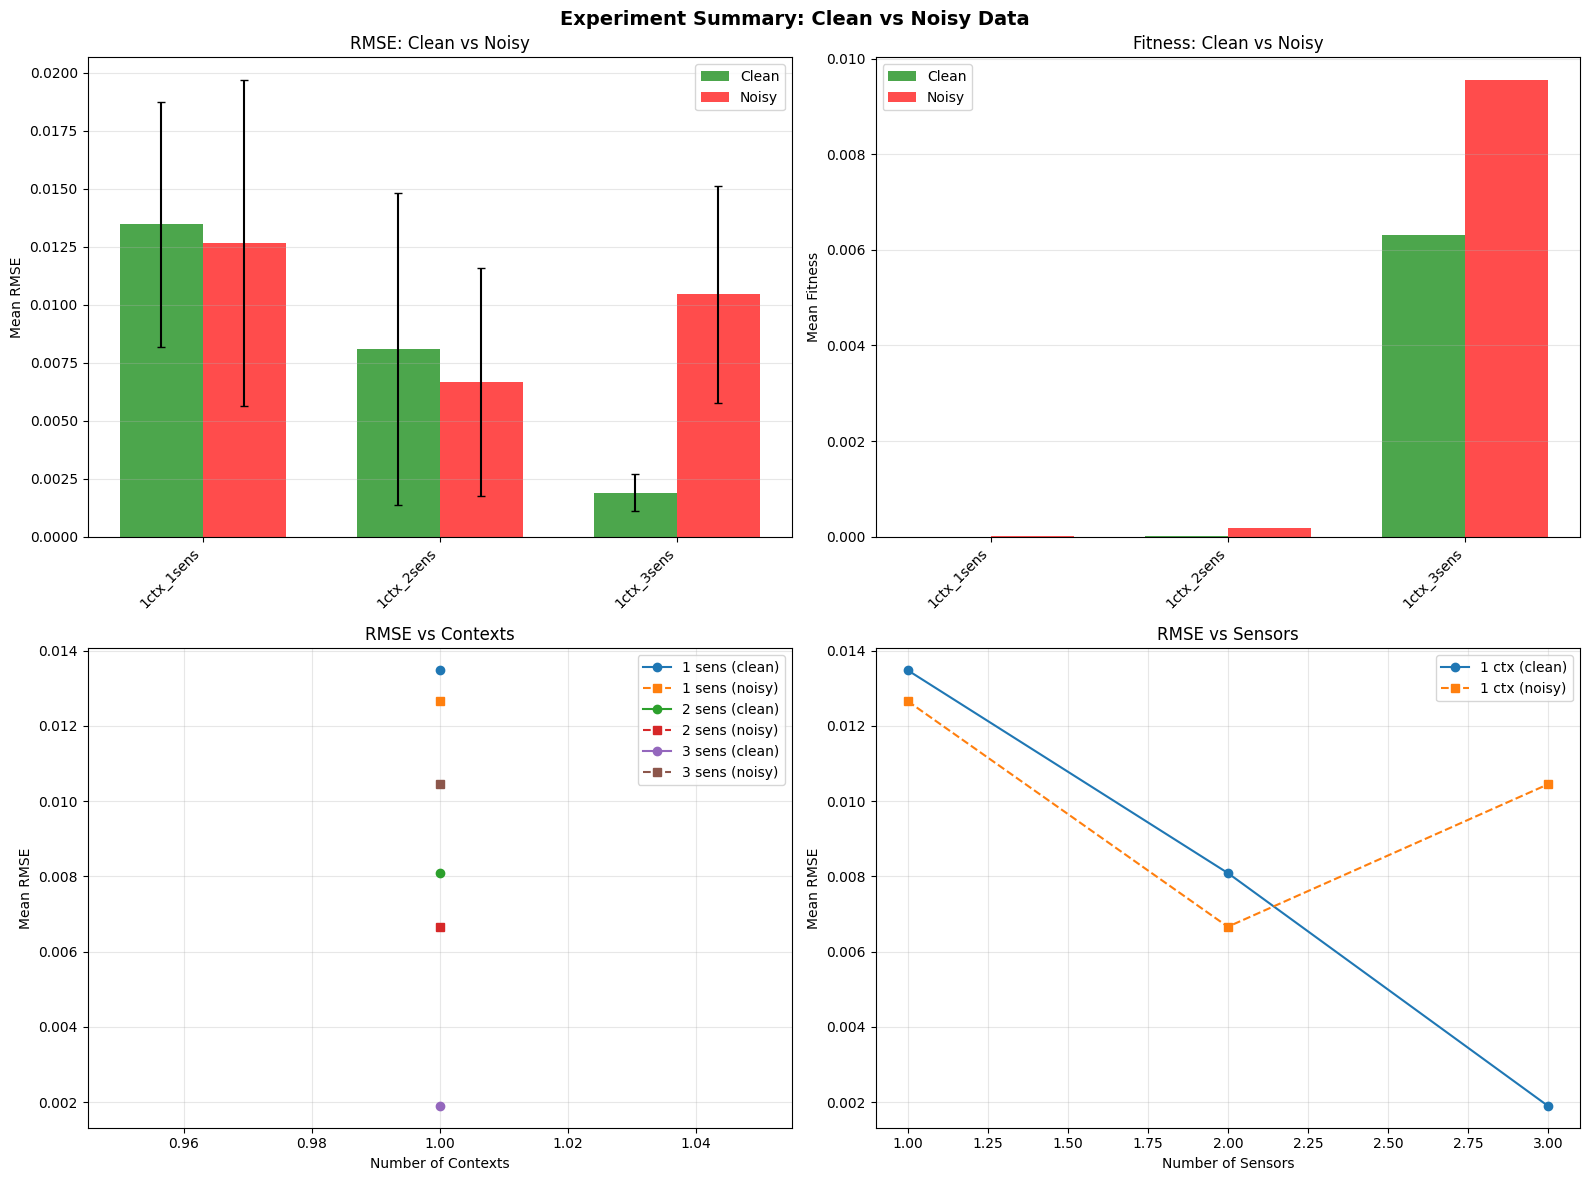

CPU times: user 657 ms, sys: 16 ms, total: 673 ms
Wall time: 672 ms


In [18]:
%%time
# Generate summary plot
plot_summary_comparison(summary_df, save_path=os.path.join(output_dir, "summary_comparison.png"))

## 5. PLot exucution time

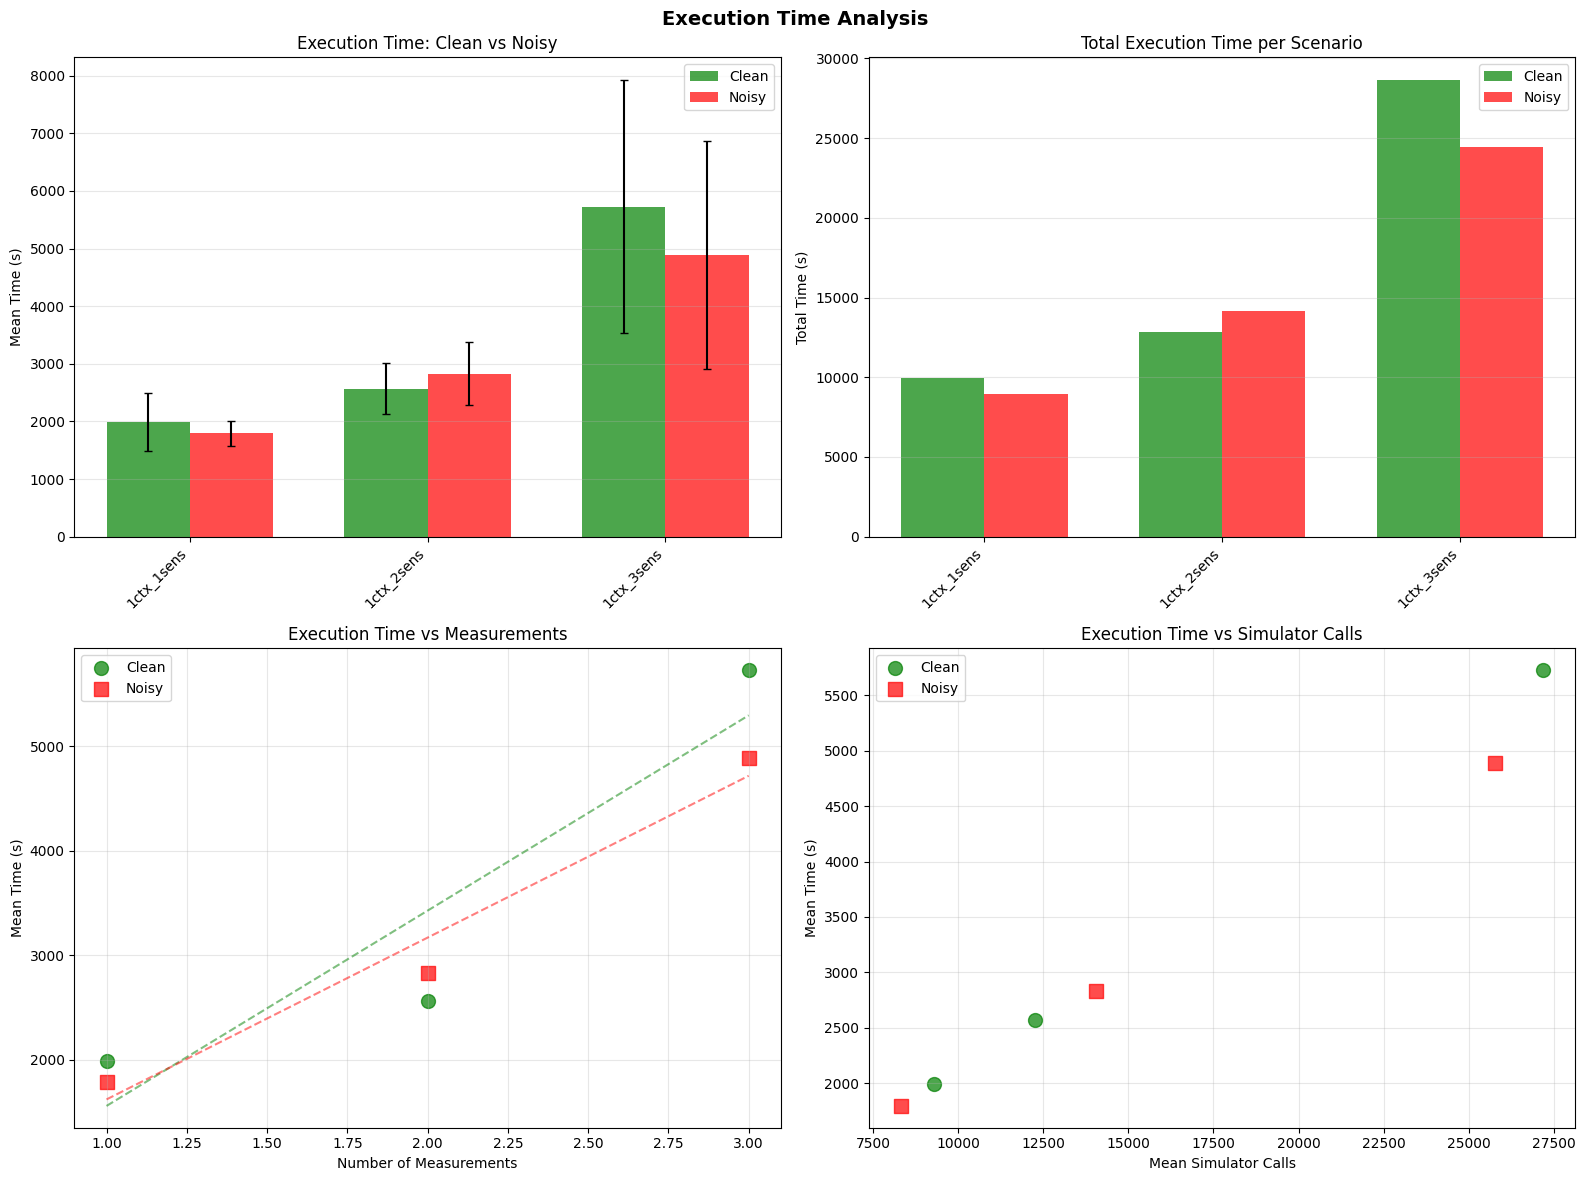

Execution time plot saved to: ../experiments/run_20260127_060402/execution_time_analysis.png
CPU times: user 664 ms, sys: 21 ms, total: 685 ms
Wall time: 684 ms


In [19]:
%%time
# Generate execution time plot
plot_execution_times(summary_df, save_path=os.path.join(output_dir, "execution_time_analysis.png"))
print(f"Execution time plot saved to: {os.path.join(output_dir, 'execution_time_analysis.png')}")

## 6. Summary of the experiemnt

Summary of the results over multiple index row

In [20]:
# Display summary table
print("\n" + "="*100)
print("EXPERIMENT SUMMARY")
print("="*100)
print(summary_df[['data_type', 'n_contexts', 'n_sensors', 'n_measurements', 
                  'mean_rmse', 'std_rmse', 'mean_fitness', 'mean_time', 'std_time', 
                  'mean_sim_calls', 'mean_generations']].to_string(index=False))

# Print timing summary
print("\n" + "="*100)
print("TIMING SUMMARY")
print("="*100)
clean_total = summary_df[summary_df['data_type']=='clean']['total_time'].sum()
noisy_total = summary_df[summary_df['data_type']=='noisy']['total_time'].sum()
print(f"Total time for CLEAN experiments: {clean_total:.1f}s ({clean_total/60:.1f} min)")
print(f"Total time for NOISY experiments: {noisy_total:.1f}s ({noisy_total/60:.1f} min)")
print(f"Grand total: {clean_total + noisy_total:.1f}s ({(clean_total + noisy_total)/60:.1f} min)")


EXPERIMENT SUMMARY
data_type  n_contexts  n_sensors  n_measurements  mean_rmse  std_rmse  mean_fitness   mean_time    std_time  mean_sim_calls  mean_generations
    clean           1          1               1   0.013478  0.005282  4.712628e-07 1991.621054  498.430412          9288.6              70.6
    clean           1          2               2   0.008089  0.006724  1.958021e-05 2564.990146  443.709904         12265.6              89.6
    clean           1          3               3   0.001899  0.000780  6.302516e-03 5727.040081 2197.077753         27190.2             197.8
    noisy           1          1               1   0.012657  0.007024  3.323540e-06 1792.919441  219.999957          8320.0              62.0
    noisy           1          2               2   0.006661  0.004911  1.698398e-04 2829.002040  552.298230         14047.6             103.2
    noisy           1          3               3   0.010447  0.004685  9.553753e-03 4887.985787 1976.384288         25768.0     

In [21]:
# Print output directory structure
print(f"\n\nAll results saved in: {output_dir}")
print("\nDirectory structure:")
for root, dirs, files in os.walk(output_dir):
    level = root.replace(output_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Limit files shown
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files)-5} more files")



All results saved in: ../experiments/run_20260127_060402

Directory structure:
run_20260127_060402/
  execution_time_analysis.png
  summary_comparison.png
  experiment_summary.csv
  clean/
    1ctx_1sensors/
      trajectory_3d.png
      multiple_solutions.csv
      convergence.png
      results_summary.png
      trajectory_3d.html
      ... and 2 more files
    1ctx_3sensors/
      trajectory_3d.png
      ablation.csv
      multiple_solutions.csv
      convergence.png
      results_summary.png
      ... and 5 more files
    1ctx_2sensors/
      trajectory_3d.png
      ablation.csv
      multiple_solutions.csv
      convergence.png
      results_summary.png
      ... and 5 more files
  noisy/
    1ctx_1sensors/
      trajectory_3d.png
      multiple_solutions.csv
      convergence.png
      results_summary.png
      trajectory_3d.html
      ... and 2 more files
    1ctx_3sensors/
      trajectory_3d.png
      ablation.csv
      multiple_solutions.csv
      convergence.png
      resul